# **Inteligência Artificial Probabilistica - Projeto Final**

### **Contents:**
1.    **Bayesian Networks**
2.    **Probabilistic classification and uncertainty quantification**
3.    **Utility theory and decision making**
4.    **Report preparation**

### **Phase 1: Preparing the dataset**

In [150]:
RANDOM_STATE = 42

In [151]:
import pandas as pd  # Librería para cargar y manipular datos en formato tabla

# Cargar dataset
df = pd.read_csv("dataset.csv", parse_dates=["date"])  # Lee el dataset del proyecto y convierte la columna date a formato fecha

print("Dataset dimensions:", df.shape)  # Muestra el número de filas (partidos) y columnas (variables) del dataset
print("Columns:")  # Mensaje informativo para listar las columnas disponibles
print(df.columns.tolist())  # Muestra los nombres de todas las variables del dataset

# Variable objetivo
target = "result"  # Resultado real del partido: H = gana local, D = empate, A = gana visitante

# Grupos de variables

team_goal_cols = [
    "date",  # Fecha del partido
    "ht",    # Home team: equipo que juega en casa
    "at",    # Away team: equipo que juega fuera
    "hg",    # Home goals: goles marcados por el equipo de casa
    "ag",    # Away goals: goles marcados por el equipo visitante
]

odds_cols = [
    "h_odds",  # Odd/cuota asociada a la victoria del equipo de casa
    "d_odds",  # Odd/cuota asociada al empate
    "a_odds",  # Odd/cuota asociada a la victoria del equipo visitante
]

form_cols = [
    "ht_form_points",           # Puntos conseguidos por el equipo de casa en sus últimos 5 partidos
    "ht_form_goals_scored",     # Goles marcados por el equipo de casa en sus últimos 5 partidos
    "ht_form_goals_conceded",   # Goles recibidos por el equipo de casa en sus últimos 5 partidos
    "ht_form_wins",             # Número de victorias del equipo de casa en sus últimos 5 partidos

    "at_form_points",           # Puntos conseguidos por el equipo visitante en sus últimos 5 partidos
    "at_form_goals_scored",     # Goles marcados por el equipo visitante en sus últimos 5 partidos
    "at_form_goals_conceded",   # Goles recibidos por el equipo visitante en sus últimos 5 partidos
    "at_form_wins",             # Número de victorias del equipo visitante en sus últimos 5 partidos

    "ht_home_form_points",          # Puntos conseguidos por el equipo de casa en sus últimos 5 partidos jugando en casa
    "ht_home_form_goals_scored",    # Goles marcados por el equipo de casa en sus últimos 5 partidos jugando en casa

    "at_away_form_points",          # Puntos conseguidos por el equipo visitante en sus últimos 5 partidos jugando fuera
    "at_away_form_goals_scored",    # Goles marcados por el equipo visitante en sus últimos 5 partidos jugando fuera
]

h2h_cols = [
    "h2h_home_wins",  # Número de victorias previas del equipo de casa contra este rival en enfrentamientos directos
    "h2h_draws",      # Número de empates previos entre ambos equipos en enfrentamientos directos
    "h2h_away_wins",  # Número de victorias previas del equipo visitante contra este rival en enfrentamientos directos
]

discrete_cols = [
    "ht_form",        # Forma reciente discretizada del equipo de casa según sus puntos en los últimos 5 partidos
    "at_form",        # Forma reciente discretizada del equipo visitante según sus puntos en los últimos 5 partidos

    "ht_attack",      # Nivel ofensivo discretizado del equipo de casa según sus goles marcados en los últimos 5 partidos
    "at_attack",      # Nivel ofensivo discretizado del equipo visitante según sus goles marcados en los últimos 5 partidos

    "joint_attack",   # Comparación conjunta entre el ataque del equipo de casa y el ataque del visitante

    "h2h_dominance",  # Dominancia histórica discretizada en enfrentamientos directos: local dominante, visitante dominante o equilibrado

    "odds_favorite",  # Favorito según las odds: local, visitante o partido equilibrado según la diferencia entre cuotas
]

# Variables para Red Bayesiana
bn_cols = discrete_cols + [target]  # Variables categóricas/discretizadas usadas para construir la Red Bayesiana y predecir result

# Variables para clasificación
classification_cols = odds_cols + form_cols + h2h_cols  # Variables numéricas usadas para entrenar clasificadores probabilísticos

print("Target variable:", target)  # Muestra cuál es la variable que se quiere predecir
print("Variables for Bayesian Network:", bn_cols)  # Muestra las variables discretizadas seleccionadas para la Red Bayesiana
print("Variables for classification:", classification_cols)  # Muestra las variables numéricas seleccionadas para clasificación

Dataset dimensions: (5583, 31)
Columns:
['date', 'ht', 'at', 'hg', 'ag', 'result', 'h_odds', 'd_odds', 'a_odds', 'ht_form_points', 'ht_form_goals_scored', 'ht_form_goals_conceded', 'ht_form_wins', 'at_form_points', 'at_form_goals_scored', 'at_form_goals_conceded', 'at_form_wins', 'ht_home_form_points', 'ht_home_form_goals_scored', 'at_away_form_points', 'at_away_form_goals_scored', 'h2h_home_wins', 'h2h_draws', 'h2h_away_wins', 'ht_form', 'at_form', 'ht_attack', 'at_attack', 'joint_attack', 'h2h_dominance', 'odds_favorite']
Target variable: result
Variables for Bayesian Network: ['ht_form', 'at_form', 'ht_attack', 'at_attack', 'joint_attack', 'h2h_dominance', 'odds_favorite', 'result']
Variables for classification: ['h_odds', 'd_odds', 'a_odds', 'ht_form_points', 'ht_form_goals_scored', 'ht_form_goals_conceded', 'ht_form_wins', 'at_form_points', 'at_form_goals_scored', 'at_form_goals_conceded', 'at_form_wins', 'ht_home_form_points', 'ht_home_form_goals_scored', 'at_away_form_points', '

In [152]:
df.head()  # Muestra las primeras filas del dataset para verificar que se ha cargado correctamente y observar el formato de los datos

,date,ht,at,hg,ag,result,h_odds,d_odds,a_odds,ht_form_points,...,h2h_home_wins,h2h_draws,h2h_away_wins,ht_form,at_form,ht_attack,at_attack,joint_attack,h2h_dominance,odds_favorite
0,2006-01-06,belenenses,gil vicente,0,2,A,1.80,3.25,4.00,10.0,...,1.0,1.0,2.0,good,below avg,average,average,average x average,balanced,home
1,2006-01-06,nacional,setubal,2,2,D,1.72,3.25,4.33,9.0,...,0.0,0.0,2.0,average,average,average,weak,average x weak,balanced,home
2,2006-01-07,maritimo,academica,2,2,D,1.72,3.25,4.33,7.0,...,0.0,1.0,3.0,average,average,average,average,average x average,balanced,home
3,2006-01-07,naval,penafiel,4,1,H,2.00,3.25,3.25,0.0,...,0.0,0.0,0.0,poor,poor,weak,weak,weak x weak,balanced,home
4,2006-01-07,sp braga,sporting,3,2,H,2.50,3.20,2.50,3.0,...,0.0,1.0,3.0,poor,good,weak,above avg,weak x above avg,balanced,balanced


In [153]:
# Número de partidos
print("Number of matches:", len(df))
print()

# Distribución de la variable objetivo
print(df[target].value_counts())
print(df[target].value_counts(normalize=True))
print()

# Valores faltantes
print(df.isna().sum())
print()

# Valores posibles de variables discretizadas
for col in discrete_cols:
    print("\n", col)
    print(df[col].value_counts())

Number of matches: 5583

result
H    2466
A    1712
D    1405
Name: count, dtype: int64
result
H    0.441698
A    0.306645
D    0.251657
Name: proportion, dtype: float64

date                         0
ht                           0
at                           0
hg                           0
ag                           0
result                       0
h_odds                       0
d_odds                       0
a_odds                       0
ht_form_points               0
ht_form_goals_scored         0
ht_form_goals_conceded       0
ht_form_wins                 0
at_form_points               0
at_form_goals_scored         0
at_form_goals_conceded       0
at_form_wins                 0
ht_home_form_points          0
ht_home_form_goals_scored    0
at_away_form_points          0
at_away_form_goals_scored    0
h2h_home_wins                0
h2h_draws                    0
h2h_away_wins                0
ht_form                      0
at_form                      0
ht_attack              

### **Phase 2: Manual Bayesian Network**

In [154]:
import pandas as pd

from IPython.display import Image
from pgmpy.models import DiscreteBayesianNetwork

# Estructura manual basada en conocimiento del dominio
manual_edges = [
    ("ht_attack", "ht_form"),
    ("at_attack", "at_form"),

    ("ht_attack", "joint_attack"),
    ("at_attack", "joint_attack"),

    ("ht_form", "odds_favorite"),
    ("at_form", "odds_favorite"),
    ("h2h_dominance", "odds_favorite"),

    ("ht_form", "result"),
    ("at_form", "result"),
    ("odds_favorite", "result"),
]

manual_bn = DiscreteBayesianNetwork(manual_edges)

print("Nodes:")
print(list(manual_bn.nodes()))

print("\nEdges:")
print(list(manual_bn.edges()))

Nodes:
['ht_attack', 'ht_form', 'at_attack', 'at_form', 'joint_attack', 'odds_favorite', 'h2h_dominance', 'result']

Edges:
[('ht_attack', 'ht_form'), ('ht_attack', 'joint_attack'), ('ht_form', 'odds_favorite'), ('ht_form', 'result'), ('at_attack', 'at_form'), ('at_attack', 'joint_attack'), ('at_form', 'odds_favorite'), ('at_form', 'result'), ('odds_favorite', 'result'), ('h2h_dominance', 'odds_favorite')]


Visual representation

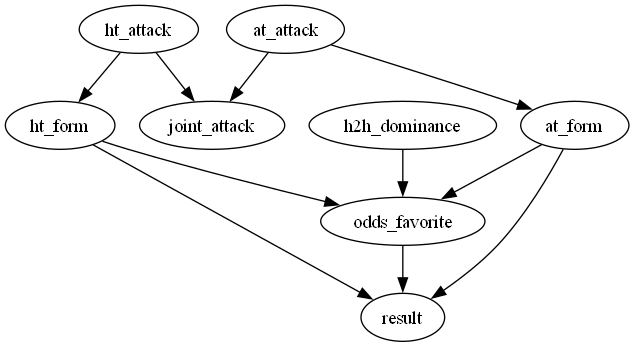

In [155]:
viz = manual_bn.to_graphviz()
viz.draw("manual_bayesian_network.png", prog="dot")

Image("manual_bayesian_network.png")

# Como todavía no hemos aprendido parámetros, no debemos usar check_model() aquí, porque el modelo aún no tiene CPDs asociadas. En la práctica, check_model() se usa después de 
# añadir las CPDs al modelo

In [156]:
print("Number of nodes:", len(manual_bn.nodes()))
print("Number of edges:", len(manual_bn.edges()))

Number of nodes: 8
Number of edges: 10


The manual Bayesian Network was constructed using a Knowledge Engineering approach.  
The structure was defined before learning the parameters, based on domain knowledge about football matches.

The variables `ht_attack` and `at_attack` are connected to `ht_form` and `at_form`, because attacking performance is part of the recent performance of each team. Both attack variables are also connected to `joint_attack`, which represents the combined attacking profile of the two teams.

The variables `ht_form`, `at_form` and `h2h_dominance` are connected to `odds_favorite`, since the betting market can reflect recent form and historical dominance between teams.

Finally, `ht_form`, `at_form` and `odds_favorite` are connected to `result`, because the result of a match can reasonably depend on the recent form of both teams and on which team is considered favorite according to the odds.

### **Phase 3: Auto-learned Bayesian network**

In [157]:
import numpy as np

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import HillClimbSearch
from pgmpy.estimators import BIC, BDeu
from IPython.display import Image

np.random.seed(RANDOM_STATE)

bn_data = df[bn_cols].copy()

# pgmpy trabaja mejor si las variables discretas están tratadas como categorías/texto
for col in bn_data.columns:
    bn_data[col] = bn_data[col].astype(str)

print("Data used for structure learning:")
print(bn_data.head())

print("\nDataset shape:")
print(bn_data.shape)

Data used for structure learning:
   ht_form    at_form ht_attack  at_attack       joint_attack h2h_dominance  \
0     good  below avg   average    average  average x average      balanced   
1  average    average   average       weak     average x weak      balanced   
2  average    average   average    average  average x average      balanced   
3     poor       poor      weak       weak        weak x weak      balanced   
4     poor       good      weak  above avg   weak x above avg      balanced   

  odds_favorite result  
0          home      A  
1          home      D  
2          home      D  
3          home      H  
4      balanced      H  

Dataset shape:
(5583, 8)


**1. Structure learned using Hill Climbing + BIC**

In [158]:
hc_bic = HillClimbSearch(bn_data)

learned_dag_bic = hc_bic.estimate(
    scoring_method=BIC(bn_data),        # puntúa esas estructuras
    max_indegree=3          # limita el número máximo de padres por nodo
)

learned_bn_bic = DiscreteBayesianNetwork(learned_dag_bic.edges())
learned_bn_bic.add_nodes_from(bn_cols)

print("Learned structure using Hill Climbing + BIC")
print("\nNodes:")
print(list(learned_bn_bic.nodes()))

print("\nEdges:")
print(list(learned_bn_bic.edges()))

print("\nNumber of edges:", len(learned_bn_bic.edges()))

C:\Users\franf\AppData\Local\Temp\ipykernel_34640\2360169562.py:1: FutureWarning: HillClimbSearch is deprecated. Please use pgmpy.causal_discovery.HillClimbSearch instead.
  hc_bic = HillClimbSearch(bn_data)


  0%|          | 0/1000000 [00:00<?, ?it/s]

Learned structure using Hill Climbing + BIC

Nodes:
['ht_attack', 'ht_form', 'at_attack', 'at_form', 'joint_attack', 'h2h_dominance', 'odds_favorite', 'result']

Edges:
[('ht_attack', 'ht_form'), ('at_attack', 'at_form'), ('joint_attack', 'at_attack'), ('joint_attack', 'ht_attack'), ('h2h_dominance', 'odds_favorite'), ('h2h_dominance', 'result'), ('h2h_dominance', 'joint_attack'), ('odds_favorite', 'joint_attack'), ('odds_favorite', 'result'), ('odds_favorite', 'at_form')]

Number of edges: 10


**2. A visual representation of the structure learned**

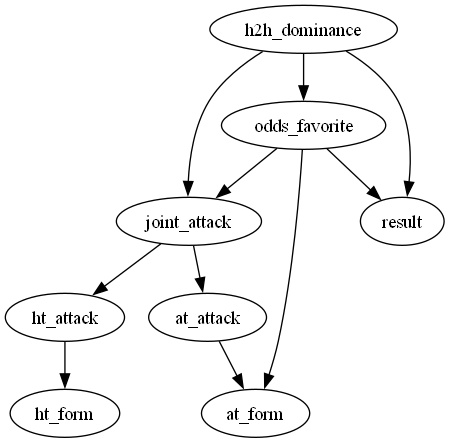

In [159]:
viz = learned_bn_bic.to_graphviz()
viz.draw("learned_bn_bic.png", prog="dot")

Image("learned_bn_bic.png")

**3. Learned Structure with Hill Climbing + BDeu**

This block is useful because it allows us to check whether the learned structure changes significantly when using a different scoring function.

In [160]:
hc_bdeu = HillClimbSearch(bn_data)

learned_dag_bdeu = hc_bdeu.estimate(
    scoring_method=BDeu(bn_data, equivalent_sample_size=5),     # usamos otra función de puntuación diferente (BDeu) que es bayesiana y tiene un parámetro adicional (equivalent_sample_size) que controla la fuerza de la penalización por complejidad del modelo
    max_indegree=3                  # mismo número de padres por nodo que antes
)

learned_bn_bdeu = DiscreteBayesianNetwork(learned_dag_bdeu.edges())
learned_bn_bdeu.add_nodes_from(bn_cols)

print("Learned structure using Hill Climbing + BDeu")
print("\nNodes:")
print(list(learned_bn_bdeu.nodes()))

print("\nEdges:")
print(list(learned_bn_bdeu.edges()))

print("\nNumber of edges:", len(learned_bn_bdeu.edges()))

C:\Users\franf\AppData\Local\Temp\ipykernel_34640\134703585.py:1: FutureWarning: HillClimbSearch is deprecated. Please use pgmpy.causal_discovery.HillClimbSearch instead.
  hc_bdeu = HillClimbSearch(bn_data)


  0%|          | 0/1000000 [00:00<?, ?it/s]

Learned structure using Hill Climbing + BDeu

Nodes:
['ht_form', 'ht_attack', 'at_form', 'odds_favorite', 'joint_attack', 'at_attack', 'h2h_dominance', 'result']

Edges:
[('ht_form', 'ht_attack'), ('ht_attack', 'joint_attack'), ('at_form', 'odds_favorite'), ('odds_favorite', 'result'), ('joint_attack', 'h2h_dominance'), ('at_attack', 'joint_attack'), ('at_attack', 'at_form'), ('h2h_dominance', 'odds_favorite'), ('h2h_dominance', 'result')]

Number of edges: 9


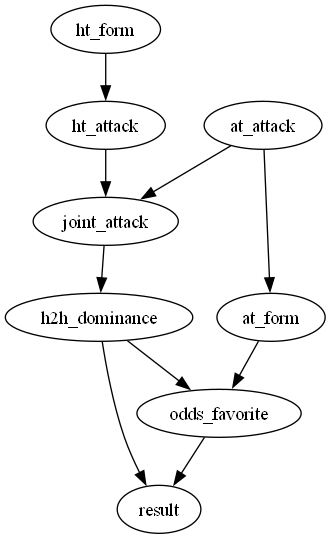

In [161]:
viz = learned_bn_bdeu.to_graphviz()
viz.draw("learned_bn_bdeu.png", prog="dot")

Image("learned_bn_bdeu.png")

We can see and interpret visually that, using this scoring function, the automatically trained Bayesian network makes less sense in terms of soccer than the previous one

**Comparison with the manual network**

This section compares the manual network with the network trained using BIC.

In [162]:
manual_edges_set = set(manual_bn.edges())
learned_edges_set = set(learned_bn_bic.edges())

common_edges = manual_edges_set.intersection(learned_edges_set)
only_manual_edges = manual_edges_set.difference(learned_edges_set)
only_learned_edges = learned_edges_set.difference(manual_edges_set)

print("Manual network edges:")
print(sorted(manual_edges_set))

print("\nLearned network edges:")
print(sorted(learned_edges_set))

print("\nCommon edges:")
print(sorted(common_edges))

print("\nEdges only in the manual network:")
print(sorted(only_manual_edges))

print("\nEdges only in the learned network:")
print(sorted(only_learned_edges))

Manual network edges:
[('at_attack', 'at_form'), ('at_attack', 'joint_attack'), ('at_form', 'odds_favorite'), ('at_form', 'result'), ('h2h_dominance', 'odds_favorite'), ('ht_attack', 'ht_form'), ('ht_attack', 'joint_attack'), ('ht_form', 'odds_favorite'), ('ht_form', 'result'), ('odds_favorite', 'result')]

Learned network edges:
[('at_attack', 'at_form'), ('h2h_dominance', 'joint_attack'), ('h2h_dominance', 'odds_favorite'), ('h2h_dominance', 'result'), ('ht_attack', 'ht_form'), ('joint_attack', 'at_attack'), ('joint_attack', 'ht_attack'), ('odds_favorite', 'at_form'), ('odds_favorite', 'joint_attack'), ('odds_favorite', 'result')]

Common edges:
[('at_attack', 'at_form'), ('h2h_dominance', 'odds_favorite'), ('ht_attack', 'ht_form'), ('odds_favorite', 'result')]

Edges only in the manual network:
[('at_attack', 'joint_attack'), ('at_form', 'odds_favorite'), ('at_form', 'result'), ('ht_attack', 'joint_attack'), ('ht_form', 'odds_favorite'), ('ht_form', 'result')]

Edges only in the lea

**Complexity comparison**

In [163]:
print("Manual network complexity")
print("Number of nodes:", len(manual_bn.nodes()))
print("Number of edges:", len(manual_bn.edges()))

print("\nLearned network complexity")
print("Number of nodes:", len(learned_bn_bic.nodes()))
print("Number of edges:", len(learned_bn_bic.edges()))

Manual network complexity
Number of nodes: 8
Number of edges: 10

Learned network complexity
Number of nodes: 8
Number of edges: 10


**Parent nodes of each variable in the trained network**

In [164]:
print("Parents of each node in the learned network:")

for node in bn_cols:
    print(f"{node}: {list(learned_bn_bic.get_parents(node))}")

# Especialmente nos interesan los padres de result:

print("Parents of result in the manual network:")
print(list(manual_bn.get_parents("result")))

print("\nParents of result in the learned network:")
print(list(learned_bn_bic.get_parents("result")))

Parents of each node in the learned network:
ht_form: ['ht_attack']
at_form: ['at_attack', 'odds_favorite']
ht_attack: ['joint_attack']
at_attack: ['joint_attack']
joint_attack: ['h2h_dominance', 'odds_favorite']
h2h_dominance: []
odds_favorite: ['h2h_dominance']
result: ['h2h_dominance', 'odds_favorite']
Parents of result in the manual network:
['ht_form', 'at_form', 'odds_favorite']

Parents of result in the learned network:
['h2h_dominance', 'odds_favorite']


**Comparison between BIC and BDeu**

In [165]:
bic_edges_set = set(learned_bn_bic.edges())
bdeu_edges_set = set(learned_bn_bdeu.edges())

print("Common edges between BIC and BDeu:")
print(sorted(bic_edges_set.intersection(bdeu_edges_set)))

print("\nEdges only in BIC structure:")
print(sorted(bic_edges_set.difference(bdeu_edges_set)))

print("\nEdges only in BDeu structure:")
print(sorted(bdeu_edges_set.difference(bic_edges_set)))

print("\nNumber of edges using BIC:", len(bic_edges_set))
print("Number of edges using BDeu:", len(bdeu_edges_set))

Common edges between BIC and BDeu:
[('at_attack', 'at_form'), ('h2h_dominance', 'odds_favorite'), ('h2h_dominance', 'result'), ('odds_favorite', 'result')]

Edges only in BIC structure:
[('h2h_dominance', 'joint_attack'), ('ht_attack', 'ht_form'), ('joint_attack', 'at_attack'), ('joint_attack', 'ht_attack'), ('odds_favorite', 'at_form'), ('odds_favorite', 'joint_attack')]

Edges only in BDeu structure:
[('at_attack', 'joint_attack'), ('at_form', 'odds_favorite'), ('ht_attack', 'joint_attack'), ('ht_form', 'ht_attack'), ('joint_attack', 'h2h_dominance')]

Number of edges using BIC: 10
Number of edges using BDeu: 9


After defining a manual Bayesian Network using domain knowledge, an automatic structure learning approach was applied.  
The goal was to learn dependencies directly from the data and compare them with the manually proposed structure.

The method used was Hill Climbing Search. This algorithm explores possible network structures and keeps changes that improve a scoring function. Two scoring functions were tested: BIC and BDeu.

The parameter `max_indegree=3` was used to avoid overly complex structures. This keeps the learned network more interpretable and closer to the objective of the project, which is not only to obtain a model but also to reason about its dependencies.

### **Phase 4: D-separation**

In [166]:
print("Global independencies:")
print(manual_bn.get_independencies())

Global independencies:
(at_form ⟂ ht_attack)
(at_form ⟂ ht_form)
(h2h_dominance ⟂ ht_attack)
(joint_attack ⟂ result | at_form, ht_form)
(at_attack ⟂ result | at_form)
(at_form ⟂ joint_attack | at_attack)
(at_attack ⟂ odds_favorite | at_form)
(joint_attack ⟂ odds_favorite | at_form, ht_form)
(h2h_dominance ⟂ ht_form)
(h2h_dominance ⟂ joint_attack)
(ht_attack ⟂ odds_favorite | ht_form)
(at_form ⟂ h2h_dominance)
(ht_attack ⟂ result | ht_form)
(ht_form ⟂ joint_attack | ht_attack)
(at_attack ⟂ ht_form)
(h2h_dominance ⟂ result | at_form, ht_form, odds_favorite)
(at_attack ⟂ h2h_dominance)
(at_attack ⟂ ht_attack)


In [167]:
print("Local independencies:")

for node in manual_bn.nodes():
    print(f"\n{node}:")
    print(manual_bn.local_independencies(node))

Local independencies:

ht_attack:
(ht_attack ⟂ at_attack, at_form, h2h_dominance)

ht_form:
(ht_form ⟂ at_attack, at_form, h2h_dominance, joint_attack | ht_attack)

at_attack:
(at_attack ⟂ h2h_dominance, ht_attack, ht_form)

at_form:
(at_form ⟂ h2h_dominance, ht_attack, ht_form, joint_attack | at_attack)

joint_attack:
(joint_attack ⟂ at_form, h2h_dominance, ht_form, odds_favorite, result | at_attack, ht_attack)

odds_favorite:
(odds_favorite ⟂ at_attack, ht_attack, joint_attack | at_form, h2h_dominance, ht_form)

h2h_dominance:
(h2h_dominance ⟂ at_attack, at_form, ht_attack, ht_form, joint_attack)

result:
(result ⟂ at_attack, h2h_dominance, ht_attack, joint_attack | at_form, ht_form, odds_favorite)


Now we will look at just a few specific cases, which are the ones we will analyze in the report.

In [168]:
dsep_cases = [
    ("ht_attack", "at_attack", []),
    ("ht_attack", "odds_favorite", ["ht_form"]),
    ("ht_form", "at_form", ["odds_favorite"]),
]

for x, y, observed in dsep_cases:
    connected = manual_bn.is_dconnected(x, y, observed=observed)
    print(f"{x} and {y} | observed={observed} -> d-connected: {connected}")

ht_attack and at_attack | observed=[] -> d-connected: False
ht_attack and odds_favorite | observed=['ht_form'] -> d-connected: False
ht_form and at_form | observed=['odds_favorite'] -> d-connected: True


### **Phase 5: Parameter Learning**

**1. Prepare data for the Bayesian network**

In [169]:
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator
from pgmpy.models import DiscreteBayesianNetwork

bn_data = df[bn_cols].copy()

for col in bn_data.columns:
    bn_data[col] = bn_data[col].astype(str)

print("Data used for parameter learning:")
print(bn_data.head())

print("\nDataset shape:")
print(bn_data.shape)

Data used for parameter learning:
   ht_form    at_form ht_attack  at_attack       joint_attack h2h_dominance  \
0     good  below avg   average    average  average x average      balanced   
1  average    average   average       weak     average x weak      balanced   
2  average    average   average    average  average x average      balanced   
3     poor       poor      weak       weak        weak x weak      balanced   
4     poor       good      weak  above avg   weak x above avg      balanced   

  odds_favorite result  
0          home      A  
1          home      D  
2          home      D  
3          home      H  
4      balanced      H  

Dataset shape:
(5583, 8)


**2. Parameter Estimation Using MLE**

In [170]:
manual_bn_mle = DiscreteBayesianNetwork(manual_bn.edges())
manual_bn_mle.add_nodes_from(manual_bn.nodes())

# MLE estima las CPTs usando frecuencias observadas en los datos
manual_bn_mle.fit(
    bn_data,
    estimator=MaximumLikelihoodEstimator
)

print("MLE model is valid:", manual_bn_mle.check_model())       # ahora sí

MLE model is valid: True


View the learned CPDs

It’s not a good idea to print the entire tables in the report, but we can view them in the notebook.

In [171]:
print("CPDs learned with MLE:")

for cpd in manual_bn_mle.get_cpds():
    print(cpd)
    print("###")

CPDs learned with MLE:
+----------------------+----------+
| ht_attack(above avg) | 0.185026 |
+----------------------+----------+
| ht_attack(average)   | 0.501343 |
+----------------------+----------+
| ht_attack(strong)    | 0.110335 |
+----------------------+----------+
| ht_attack(weak)      | 0.203296 |
+----------------------+----------+
###
+--------------------+-----+----------------------+
| ht_attack          | ... | ht_attack(weak)      |
+--------------------+-----+----------------------+
| ht_form(average)   | ... | 0.06784140969162995  |
+--------------------+-----+----------------------+
| ht_form(below avg) | ... | 0.42555066079295156  |
+--------------------+-----+----------------------+
| ht_form(excellent) | ... | 0.0                  |
+--------------------+-----+----------------------+
| ht_form(good)      | ... | 0.001762114537444934 |
+--------------------+-----+----------------------+
| ht_form(poor)      | ... | 0.5048458149779735   |
+--------------------+---

**3. Parameter learning using Bayesian estimation**

In [172]:
manual_bn_bayes = DiscreteBayesianNetwork(manual_bn.edges())
manual_bn_bayes.add_nodes_from(manual_bn.nodes())

# La estimación bayesiana suaviza las probabilidades usando un prior
manual_bn_bayes.fit(
    bn_data,
    estimator=BayesianEstimator,
    prior_type="BDeu",                      # alternativa: k2 (suma 1 a cada fila de la CPT, independientemente del número de categorías)
    equivalent_sample_size=5        # indica cuánta fuerza tiene ese prior --> el suavizado es moderado: no domina al dataset real, pero ayuda a evitar probabilidades extremas cuando hay combinaciones poco frecuentes
)

print("Bayesian model is valid:", manual_bn_bayes.check_model())

Bayesian model is valid: True


In [173]:
print("CPDs learned with Bayesian Estimation:")

for cpd in manual_bn_bayes.get_cpds():
    print(cpd)
    print("###")

CPDs learned with Bayesian Estimation:
+----------------------+----------+
| ht_attack(above avg) | 0.185084 |
+----------------------+----------+
| ht_attack(average)   | 0.501118 |
+----------------------+----------+
| ht_attack(strong)    | 0.11046  |
+----------------------+----------+
| ht_attack(weak)      | 0.203338 |
+----------------------+----------+
###
+--------------------+-----+------------------------+
| ht_attack          | ... | ht_attack(weak)        |
+--------------------+-----+------------------------+
| ht_form(average)   | ... | 0.06798679867986798    |
+--------------------+-----+------------------------+
| ht_form(below avg) | ... | 0.4253025302530253     |
+--------------------+-----+------------------------+
| ht_form(excellent) | ... | 0.00022002200220022002 |
+--------------------+-----+------------------------+
| ht_form(good)      | ... | 0.0019801980198019802  |
+--------------------+-----+------------------------+
| ht_form(poor)      | ... | 0.50451045

**4. Compare a relevant CPT: result**

The most important CPT is the result CPT, because it is the project's target variable

In [174]:
cpd_result_mle = manual_bn_mle.get_cpds("result")
cpd_result_bayes = manual_bn_bayes.get_cpds("result")

print("CPD of result learned with MLE:")
print(cpd_result_mle)

print("\nCPD of result learned with Bayesian Estimation:")
print(cpd_result_bayes)

CPD of result learned with MLE:
+---------------+-----+---------------------+
| at_form       | ... | at_form(poor)       |
+---------------+-----+---------------------+
| ht_form       | ... | ht_form(poor)       |
+---------------+-----+---------------------+
| odds_favorite | ... | odds_favorite(home) |
+---------------+-----+---------------------+
| result(A)     | ... | 0.2966101694915254  |
+---------------+-----+---------------------+
| result(D)     | ... | 0.2966101694915254  |
+---------------+-----+---------------------+
| result(H)     | ... | 0.4067796610169492  |
+---------------+-----+---------------------+

CPD of result learned with Bayesian Estimation:
+---------------+-----+---------------------+
| at_form       | ... | at_form(poor)       |
+---------------+-----+---------------------+
| ht_form       | ... | ht_form(poor)       |
+---------------+-----+---------------------+
| odds_favorite | ... | odds_favorite(home) |
+---------------+-----+---------------------+

Since this table may be large, it's best to view it as a DataFrame:

In [175]:
result_mle_df = cpd_result_mle.to_dataframe()
result_bayes_df = cpd_result_bayes.to_dataframe()

print("Result CPD - MLE")
display(result_mle_df)

print("Result CPD - Bayesian Estimation")
display(result_bayes_df)

Result CPD - MLE


result                                  A         D         H
at_form ht_form   odds_favorite                              
average average   away           0.551724  0.287356  0.160920
                  balanced       0.437500  0.234375  0.328125
                  home           0.245968  0.274194  0.479839
        below avg away           0.589147  0.224806  0.186047
                  balanced       0.384615  0.318681  0.296703
...                                   ...       ...       ...
poor    good      balanced       0.000000  0.500000  0.500000
                  home           0.085470  0.222222  0.692308
        poor      away           0.461538  0.153846  0.384615
                  balanced       0.323529  0.294118  0.382353
                  home           0.296610  0.296610  0.406780

[75 rows x 3 columns]

Result CPD - Bayesian Estimation


result                                  A         D         H
at_form ht_form   odds_favorite                              
average average   away           0.551557  0.287392  0.161052
                  balanced       0.437392  0.234478  0.328130
                  home           0.245991  0.274209  0.479799
        below avg away           0.589015  0.224862  0.186123
                  balanced       0.384578  0.318692  0.296730
...                                   ...       ...       ...
poor    good      balanced       0.010753  0.494624  0.494624
                  home           0.085611  0.222285  0.692103
        poor      away           0.460884  0.154762  0.384354
                  balanced       0.323549  0.294194  0.382257
                  home           0.296631  0.296631  0.406738

[75 rows x 3 columns]

We can see that when using MLE, in some cases the probability is 0, which may not be feasible in reality

It’s also a bit strange because when the home team’s form is good and the away team’s is poor, and the bookmaker doesn’t list either team as the favorite, it’s a bit odd that the away team’s probability is 0. However, if we keep the same situation but the bookmaker lists the home team as the favorite, then the away team does have some probability, even if it’s low

If we compare the two situations using Bayesian Optimization, we see that the probabilities make much more sense in terms of soccer, and there are no extreme cases with a probability of 0.

**5. Compare specific cases**

Now we’ll present some interpretable probabilities. This is better than filling the report with huge tables

In [176]:
# pgmpy convierte la CPT de result en un DataFrame. Pero muchas veces las variables condicionantes no quedan como columnas normales, sino como parte del índice del DataFrame.
# Por eso reseteamos el índice para que las variables condicionantes (ht_form, at_form, odds_favorite) queden como columnas normales y podamos filtrarlas fácilmente para 
# comparar casos concretos entre MLE y Bayesiano
result_mle_table = result_mle_df.reset_index()
result_bayes_table = result_bayes_df.reset_index()

def filter_result_cpd(cpd_table, ht_form_value, at_form_value, odds_favorite_value):
    return cpd_table[
        (cpd_table["ht_form"] == ht_form_value) &
        (cpd_table["at_form"] == at_form_value) &
        (cpd_table["odds_favorite"] == odds_favorite_value)
    ]

case_1_mle = filter_result_cpd(
    result_mle_table,
    ht_form_value="good",
    at_form_value="average",
    odds_favorite_value="home"
)

case_1_bayes = filter_result_cpd(
    result_bayes_table,
    ht_form_value="good",
    at_form_value="average",
    odds_favorite_value="home"
)

print("Case 1 - MLE")
display(case_1_mle)

print("Case 1 - Bayesian Estimation")
display(case_1_bayes)

Case 1 - MLE


result,at_form,ht_form,odds_favorite,A,D,H
11,average,good,home,0.132597,0.19337,0.674033


Case 1 - Bayesian Estimation


result,at_form,ht_form,odds_favorite,A,D,H
11,average,good,home,0.132671,0.193422,0.673908


In this specific configuration, MLE and Bayesian estimation yield probabilities that are virtually identical. This suggests that this is not a rare combination in the dataset, so Bayesian smoothing does not need to significantly adjust the frequency-based estimate.

That 11 doesn't mean the result is 11.

It's simply the old row index, which, after calling `reset_index()`, has become a column named `result`. It's a somewhat confusing detail regarding how pgmpy names the table when converting the CPT to a DataFrame.

**6. Comparing a case with limited data**

This section helps us explain why Bayesian estimation can be useful

In [177]:
parent_counts = (
    bn_data
    .groupby(["ht_form", "at_form", "odds_favorite"])           # Primero agrupa los datos por las variables que son padres de result en la red manual
    .size()                             # cuenta cuántas filas hay en cada grupo (e.g para ht_form=good, at_form=average, odds_favorite=home, cuántos partidos hay en el dataset con esa combinación de padres)
    .reset_index(name="count")      # convierte el resultado en una tabla normal y llama count a la columna de conteo
    .sort_values("count")               # ordena las combinaciones desde la menos frecuente hasta la más frecuente
)

print("Least frequent parent configurations for result:")
display(parent_counts.head(10))

Least frequent parent configurations for result:


,ht_form,at_form,odds_favorite,count
12,average,poor,away,2
31,excellent,average,balanced,2
30,excellent,average,away,2
63,poor,excellent,home,2
53,good,poor,balanced,2
35,excellent,excellent,balanced,3
23,below avg,excellent,home,4
22,below avg,excellent,balanced,4
34,excellent,excellent,away,5
7,average,excellent,balanced,5


Now let's choose one of the less common combinations and compare MLE and Bayes

In [178]:
rare_case = parent_counts.iloc[0]

rare_ht_form = rare_case["ht_form"]
rare_at_form = rare_case["at_form"]
rare_odds_favorite = rare_case["odds_favorite"]

rare_case_mle = filter_result_cpd(
    result_mle_table,
    ht_form_value=rare_ht_form,
    at_form_value=rare_at_form,
    odds_favorite_value=rare_odds_favorite
)

rare_case_bayes = filter_result_cpd(
    result_bayes_table,
    ht_form_value=rare_ht_form,
    at_form_value=rare_at_form,
    odds_favorite_value=rare_odds_favorite
)

print("Rare parent configuration:")
print(rare_case.to_dict())

print("\nRare case - MLE")
display(rare_case_mle)

print("Rare case - Bayesian Estimation")
display(rare_case_bayes)

Rare parent configuration:
{'ht_form': 'average', 'at_form': 'poor', 'odds_favorite': 'away', 'count': 2}

Rare case - MLE


result,at_form,ht_form,odds_favorite,A,D,H
60,poor,average,away,0.0,0.5,0.5


Rare case - Bayesian Estimation


result,at_form,ht_form,odds_favorite,A,D,H
60,poor,average,away,0.010753,0.494624,0.494624


**7. Detecting extreme probabilities in the CPT of the result**

This allows us to check whether MLE produces probabilities of 0 or 1

In [179]:
# Columnas que contienen las probabilidades de cada clase
mle_prob_cols = ["A", "D", "H"]
bayes_prob_cols = ["A", "D", "H"]

mle_extreme_rows = result_mle_table[
    (result_mle_table[mle_prob_cols] == 0).any(axis=1) |        # Para cada fila, comprueba si al menos una de las columnas A, D o H cumple esa condición
    (result_mle_table[mle_prob_cols] == 1).any(axis=1)
]

bayes_extreme_rows = result_bayes_table[
    (result_bayes_table[bayes_prob_cols] == 0).any(axis=1) |
    (result_bayes_table[bayes_prob_cols] == 1).any(axis=1)
]

print("Number of extreme rows in result CPD using MLE:", len(mle_extreme_rows))
print("Number of extreme rows in result CPD using Bayesian Estimation:", len(bayes_extreme_rows))

Number of extreme rows in result CPD using MLE: 8
Number of extreme rows in result CPD using Bayesian Estimation: 0


There are 8 situations in which extreme probabilities occur when using MLE, whereas none occur when using Bayesian estimation

### **Phase 6: Probabilistic inferences**

In [180]:
from pgmpy.inference import VariableElimination

infer = VariableElimination(manual_bn_bayes)        # algoritmo de inferencia exacta basado en eliminación de variables

### **Basic quiries**

**Query 1 - Home team in good form and favorite in odds**

In [181]:
q1 = infer.query(
    variables=["result"],
    evidence={
        "ht_form": "good",
        "odds_favorite": "home"
    }
)

print("Query 1: P(result | ht_form=good, odds_favorite=home)")
print(q1)

Query 1: P(result | ht_form=good, odds_favorite=home)
+-----------+---------------+
| result    |   phi(result) |
+===========+===============+
| result(A) |        0.1164 |
+-----------+---------------+
| result(D) |        0.1884 |
+-----------+---------------+
| result(H) |        0.6952 |
+-----------+---------------+


**Query 2 - Both teams with average form**

In [182]:
q2 = infer.query(
    variables=["result"],
    evidence={
        "ht_form": "average",
        "at_form": "average"
    }
)

print("Query 2: P(result | ht_form=average, at_form=average)")
print(q2)

Query 2: P(result | ht_form=average, at_form=average)
+-----------+---------------+
| result    |   phi(result) |
+===========+===============+
| result(A) |        0.3404 |
+-----------+---------------+
| result(D) |        0.2706 |
+-----------+---------------+
| result(H) |        0.3890 |
+-----------+---------------+


**Query 3 - Home dominance in head-to-head**

In [183]:
q3 = infer.query(
    variables=["result"],
    evidence={
        "h2h_dominance": "home_dominant"
    }
)

print("Query 3: P(result | h2h_dominance=home_dominant)")
print(q3)

Query 3: P(result | h2h_dominance=home_dominant)
+-----------+---------------+
| result    |   phi(result) |
+===========+===============+
| result(A) |        0.2050 |
+-----------+---------------+
| result(D) |        0.2485 |
+-----------+---------------+
| result(H) |        0.5464 |
+-----------+---------------+


**Query 4 - Away team favorite despite home team good form**

In [184]:
q4 = infer.query(
    variables=["result"],
    evidence={
        "ht_form": "good",
        "odds_favorite": "away"
    }
)

print("Query 4: P(result | ht_form=good, odds_favorite=away)")
print(q4)

Query 4: P(result | ht_form=good, odds_favorite=away)
+-----------+---------------+
| result    |   phi(result) |
+===========+===============+
| result(A) |        0.5681 |
+-----------+---------------+
| result(D) |        0.2978 |
+-----------+---------------+
| result(H) |        0.1341 |
+-----------+---------------+


Save query results to a table

In [185]:
queries = {
    "Q1_home_good_and_favorite": q1,
    "Q2_both_average_form": q2,
    "Q3_home_dominant_h2h": q3,
    "Q4_home_good_but_away_favorite": q4,
}

query_results = []

for query_name, query_result in queries.items():
    probs = query_result.values
    states = query_result.state_names["result"]
    
    row = {"query": query_name}
    
    for state, prob in zip(states, probs):
        row[state] = prob
    
    query_results.append(row)

query_results_df = pd.DataFrame(query_results)

print("Probabilistic inference results:")
display(query_results_df)

Probabilistic inference results:


,query,A,D,H
0,Q1_home_good_and_favorite,0.116365,0.188434,0.695201
1,Q2_both_average_form,0.340393,0.270617,0.388990
2,Q3_home_dominant_h2h,0.205013,0.248538,0.546449
3,Q4_home_good_but_away_favorite,0.568051,0.297800,0.134149


### **Advanced queries**

In [186]:
advanced_queries = {
    # Q5: Local en baja forma, visitante en alta forma, pero favorito local
    "Q5_poor_home_excellent_away_home_favorite": {
        "ht_form": "poor",
        "at_form": "excellent",
        "odds_favorite": "home"
    },

    # Q6: Local en buena forma, con ataque débil, pero favorito visitante
    "Q6_good_home_weak_attack_away_favorite": {
        "ht_form": "good",
        "ht_attack": "weak",
        "odds_favorite": "away"
    },

    # Q7: Dominancia histórica local, pero favorito visitante
    "Q7_home_dominance_away_favorite": {
        "h2h_dominance": "home_dominant",
        "odds_favorite": "away"
    },

    # Q8: Dominancia histórica local, pero visitante en buena forma
    "Q8_home_dominance_away_good_form": {
        "h2h_dominance": "home_dominant",
        "at_form": "good"
    },

    # Q9: Ambos equipos llegan en excelente forma
    "Q9_both_excellent_form": {
        "ht_form": "excellent",
        "at_form": "excellent"
    },

    # Q10: Local con ataque fuerte y visitante con ataque débil
    "Q10_strong_home_attack_weak_away_attack": {
        "ht_attack": "strong",
        "at_attack": "weak"
    },

    # Q11: Local con ataque débil y visitante con ataque fuerte
    "Q11_weak_home_attack_strong_away_attack": {
        "ht_attack": "weak",
        "at_attack": "strong"
    },

    # Q12: Partido equilibrado según forma reciente y odds
    "Q12_balanced_match": {
        "ht_form": "average",
        "at_form": "average",
        "odds_favorite": "balanced"
    },

    # Q13: Local favorito, pero visitante con mejor forma reciente
    "Q13_home_favorite_but_away_better_form": {
        "ht_form": "below avg",
        "at_form": "good",
        "odds_favorite": "home"
    },

    # Q14: Visitante favorito, pero local con mejor forma reciente
    "Q14_away_favorite_but_home_better_form": {
        "ht_form": "good",
        "at_form": "below avg",
        "odds_favorite": "away"
    },

    # Q15: Dominancia histórica visitante, pero favorito local
    "Q15_away_dominance_home_favorite": {
        "h2h_dominance": "away_dominant",
        "odds_favorite": "home"
    }
}

In [187]:
advanced_query_results = []

for query_name, evidence in advanced_queries.items():
    q = infer.query(
        variables=["result"],
        evidence=evidence
    )
    
    probs = q.values
    states = q.state_names["result"]
    
    row = {
        "query": query_name,
        "evidence": evidence
    }
    
    for state, prob in zip(states, probs):
        row[state] = prob
    
    advanced_query_results.append(row)

advanced_query_results_df = pd.DataFrame(advanced_query_results)

print("Advanced probabilistic inference results:")
display(advanced_query_results_df)

Advanced probabilistic inference results:


,query,evidence,A,D,H
0,Q5_poor_home_excellent_away_home_favorite,"{'ht_form': 'poor', 'at_form': 'excellent', 'o...",0.494624,0.010753,0.494624
1,Q6_good_home_weak_attack_away_favorite,"{'ht_form': 'good', 'ht_attack': 'weak', 'odds...",0.568051,0.297800,0.134149
2,Q7_home_dominance_away_favorite,"{'h2h_dominance': 'home_dominant', 'odds_favor...",0.606284,0.223081,0.170635
3,Q8_home_dominance_away_good_form,"{'h2h_dominance': 'home_dominant', 'at_form': ...",0.179446,0.224619,0.595936
4,Q9_both_excellent_form,"{'ht_form': 'excellent', 'at_form': 'excellent'}",0.135268,0.335443,0.529288
5,Q10_strong_home_attack_weak_away_attack,"{'ht_attack': 'strong', 'at_attack': 'weak'}",0.105005,0.181165,0.713829
6,Q11_weak_home_attack_strong_away_attack,"{'ht_attack': 'weak', 'at_attack': 'strong'}",0.509461,0.210836,0.279703
7,Q12_balanced_match,"{'ht_form': 'average', 'at_form': 'average', '...",0.437392,0.234478,0.328130
8,Q13_home_favorite_but_away_better_form,"{'ht_form': 'below avg', 'at_form': 'good', 'o...",0.196591,0.267935,0.535474
9,Q14_away_favorite_but_home_better_form,"{'ht_form': 'good', 'at_form': 'below avg', 'o...",0.498623,0.374656,0.126722


### **Step 7: Naive Bayes Classifier and Logistic Regression**

**Train and evaluate Naive Bayes**

In [188]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB           # Es la versión de Naive Bayes adecuada para variables categóricas/discretizadas
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, log_loss

np.random.seed(RANDOM_STATE)

nb_features = discrete_cols.copy()

# Creo que ya estaba ordenado el dataset temporalmente, pero aquí nos aseguramos
df_sorted = df.sort_values("date").reset_index(drop=True)

X_nb = df_sorted[nb_features].copy()    
y = df_sorted[target].copy()

for col in X_nb.columns:
    X_nb[col] = X_nb[col].astype(str)

print("Naive Bayes features:")
print(nb_features)

print("\nTarget distribution:")
print(y.value_counts(normalize=True))

Naive Bayes features:
['ht_form', 'at_form', 'ht_attack', 'at_attack', 'joint_attack', 'h2h_dominance', 'odds_favorite']

Target distribution:
result
H    0.441698
A    0.306645
D    0.251657
Name: proportion, dtype: float64


**Temporal train / calibration / test split**

In [189]:
n = len(df_sorted)

train_end = int(n * 0.65)       # los primeros 65% de los partidos para entrenamiento
calib_end = int(n * 0.82)       # siguiente 17% para calibración (ajuste de umbrales o parámetros adicionales del modelo usando un conjunto de validación separado)
                                        # último 18% para test (evaluación final del modelo)
X_nb_train = X_nb.iloc[:train_end]
y_train = y.iloc[:train_end]

X_nb_calib = X_nb.iloc[train_end:calib_end]
y_calib = y.iloc[train_end:calib_end]

X_nb_test = X_nb.iloc[calib_end:]
y_test = y.iloc[calib_end:]

print("Train size:", len(X_nb_train))
print("Calibration size:", len(X_nb_calib))
print("Test size:", len(X_nb_test))

print("\nTrain period:", df_sorted["date"].iloc[0], "to", df_sorted["date"].iloc[train_end - 1])
print("Calibration period:", df_sorted["date"].iloc[train_end], "to", df_sorted["date"].iloc[calib_end - 1])
print("Test period:", df_sorted["date"].iloc[calib_end], "to", df_sorted["date"].iloc[-1])

Train size: 3628
Calibration size: 950
Test size: 1005

Train period: 2006-01-06 00:00:00 to 2019-09-22 00:00:00
Calibration period: 2019-09-22 00:00:00 to 2022-10-22 00:00:00
Test period: 2022-10-22 00:00:00 to 2026-01-26 00:00:00


**Encode categorical variables**

Convert the categories to integers so that CategoricalNB can work with them. Scikit-learn does not train directly on text. We need to convert values such as “excellent” or “balanced” into numerical codes.

In [190]:
# CategoricalNB necesita que las variables categóricas estén convertidas a números. Además, queremos evaluar tanto la clase predicha como la calidad de las probabilidades
encoder_nb = OrdinalEncoder(                        # Convierte categorías como "good", "poor" o "home" en números
    handle_unknown="use_encoded_value",     # Permite manejar categorías que aparezcan en calibración o test pero no en entrenamiento. En lugar de lanzar un error, asigna un valor numérico específico (en este caso -1) a esas categorías desconocidas
    unknown_value=-1
)

X_nb_train_enc = encoder_nb.fit_transform(X_nb_train)       # Aprende las categorías usando solo entrenamiento y transforma esos datos
X_nb_calib_enc = encoder_nb.transform(X_nb_calib)       # aplica la misma codificación a calibración y test. No se hace fit aquí para evitar usar información futura
X_nb_test_enc = encoder_nb.transform(X_nb_test)

# Sumamos 1 para evitar valores negativos en CategoricalNB --> CategoricalNB no acepta valores negativos. Así, si había un -1, pasa a 0.
X_nb_train_enc = X_nb_train_enc + 1
X_nb_calib_enc = X_nb_calib_enc + 1
X_nb_test_enc = X_nb_test_enc + 1

# OrdinalEncoder también codifica las categorías conocidas empezando en 0. Es decir, una categoría real del entrenamiento también podría tener código 0.
# La opción más limpia es reservar el 0 para categorías desconocidas y hacer que las categorías conocidas empiecen en 1. Pero OrdinalEncoder no permite directamente empezar 
# las categorías conocidas en 1, por eso usamos: unknown_value=-1

**Train Naive Bayes**

In [191]:
nb_model = CategoricalNB()

nb_model.fit(X_nb_train_enc, y_train)

print("Naive Bayes model trained.")
print("Classes:", nb_model.classes_)

Naive Bayes model trained.
Classes: ['A' 'D' 'H']


**Predict classes and probabilities**

The project doesn't just need to know whether the model predicts H, D, or A. It needs the probabilities to measure uncertainty, calibration, conformal prediction, and utility

In [192]:
# Obtiene tanto la clase predicha como las probabilidades para cada clase
y_calib_pred_nb = nb_model.predict(X_nb_calib_enc)
y_test_pred_nb = nb_model.predict(X_nb_test_enc)

y_calib_proba_nb = nb_model.predict_proba(X_nb_calib_enc)
y_test_proba_nb = nb_model.predict_proba(X_nb_test_enc)

print("Predicted probability matrix shape:", y_test_proba_nb.shape)
print("Class order:", nb_model.classes_)

Predicted probability matrix shape: (1005, 3)
Class order: ['A' 'D' 'H']


**Store probabilistic predictions**

In [193]:
# Convierte la matriz de probabilidades en un DataFrame con nombres claros
nb_proba_test = pd.DataFrame(
    y_test_proba_nb,
    columns=[f"P_{class_name}" for class_name in nb_model.classes_],        # crea columnas como P_H, P_D, P_A para las probabilidades de cada clase
    index=y_test.index      # Mantiene el índice original del conjunto de test para poder unirlo correctamente con fecha, equipos y resultado real
)

# Crea una tabla resumen con información del partido, resultado real y predicción
nb_test_results = pd.DataFrame({
    "date": df_sorted.loc[y_test.index, "date"],
    "ht": df_sorted.loc[y_test.index, "ht"],
    "at": df_sorted.loc[y_test.index, "at"],
    "true_result": y_test,
    "predicted_result": y_test_pred_nb,
})

# Une la tabla de partidos con las probabilidades predichas.
nb_test_results = pd.concat([nb_test_results, nb_proba_test], axis=1)

print("First probabilistic predictions:")
display(nb_test_results.head())

First probabilistic predictions:


,date,ht,at,true_result,predicted_result,P_A,P_D,P_H
4578,2022-10-22,estoril,sp braga,A,A,0.719414,0.213373,0.067214
4579,2022-10-22,sporting,casa pia,H,H,0.005158,0.040704,0.954138
4580,2022-10-23,maritimo,arouca,D,A,0.513750,0.367634,0.118617
4581,2022-10-23,vizela,santa clara,A,D,0.142279,0.452399,0.405322
4582,2022-10-23,chaves,gil vicente,H,D,0.256858,0.526788,0.216354


**Basic evaluation**

We want to evaluate both the accuracy of the classes and the probabilistic quality

In [194]:
# Calcula métricas de rendimiento
nb_accuracy = accuracy_score(y_test, y_test_pred_nb)
nb_balanced_accuracy = balanced_accuracy_score(y_test, y_test_pred_nb)      # Calcula el rendimiento teniendo en cuenta el posible desbalance entre clases. Es útil porque H, D y A no aparecen con la misma frecuencia
nb_log_loss = log_loss(y_test, y_test_proba_nb, labels=nb_model.classes_)       # Evalúa probabilidades. Penaliza especialmente cuando el modelo se equivoca con mucha confianza

print("Naive Bayes accuracy:", nb_accuracy)
print("Naive Bayes balanced accuracy:", nb_balanced_accuracy)
print("Naive Bayes log loss:", nb_log_loss)

print("\nClassification report:")
print(classification_report(y_test, y_test_pred_nb))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_test_pred_nb, labels=nb_model.classes_))

print("\nClass order:")
print(nb_model.classes_)

Naive Bayes accuracy: 0.5482587064676617
Naive Bayes balanced accuracy: 0.4998014178689641
Naive Bayes log loss: 1.1452408990766145

Classification report:
              precision    recall  f1-score   support

           A       0.57      0.59      0.58       323
           D       0.33      0.22      0.26       236
           H       0.60      0.70      0.65       446

    accuracy                           0.55      1005
   macro avg       0.50      0.50      0.49      1005
weighted avg       0.53      0.55      0.53      1005


Confusion matrix:
[[190  44  89]
 [ 70  51 115]
 [ 75  61 310]]

Class order:
['A' 'D' 'H']


**Also save the calibration for Conformal Prediction**

The calibration dataset will be required for Split Conformal Prediction as well as for post-hoc calibration

In [195]:
# Guarda las probabilidades predichas sobre el conjunto de calibración
nb_proba_calib = pd.DataFrame(
    y_calib_proba_nb,
    columns=[f"P_{class_name}" for class_name in nb_model.classes_],
    index=y_calib.index
)

# Crea una tabla equivalente a la de test, pero para calibración
nb_calib_results = pd.DataFrame({
    "date": df_sorted.loc[y_calib.index, "date"],
    "ht": df_sorted.loc[y_calib.index, "ht"],
    "at": df_sorted.loc[y_calib.index, "at"],
    "true_result": y_calib,
    "predicted_result": y_calib_pred_nb,
})

# Une la información de los partidos de calibración con sus probabilidades --> Este DataFrame será usado para construir los prediction sets en Conformal Prediction
nb_calib_results = pd.concat([nb_calib_results, nb_proba_calib], axis=1)

print("Calibration results shape:", nb_calib_results.shape)
print("Test results shape:", nb_test_results.shape)

Calibration results shape: (950, 8)
Test results shape: (1005, 8)


### **2 Aplicar Conformal Prediction sobre Naive Bayes**

**Define error level and calculate nonconformity scores during calibration**

We use the following score:

score = 1 - P(true class)

If the model assigns a high probability to the correct class, the score will be low.
If it assigns a low probability to the correct class, the score will be high.

In [196]:
# 1. Definir nivel de error
alpha = 0.10
print("Target coverage:", 1 - alpha)

# 2. Calcular nonconformity scores en calibración --> Calcula, para cada partido del conjunto de calibración, cuánto “fallaba” el modelo respecto a la clase real
class_to_index = {class_name: i for i, class_name in enumerate(nb_model.classes_)}      # {'A': 0, 'D': 1, 'H': 2} --> Esto es necesario porque predict_proba devuelve una matriz de probabilidades siguiendo el orden de nb_model.classes_
calib_scores = []
for i, true_label in enumerate(y_calib):        # Recorre cada partido de calibración junto con su posición
    true_class_index = class_to_index[true_label]           # Busca qué columna corresponde a la clase real del partido
    true_class_probability = y_calib_proba_nb[i, true_class_index]              # Extrae la probabilidad que el modelo asignó al resultado verdadero
    calib_scores.append(1 - true_class_probability)             # Guarda el score de no conformidad

calib_scores = np.array(calib_scores)
print("First calibration scores:")
print(calib_scores[:10])

# Conformal Prediction necesita un conjunto de calibración para medir qué tan conformes o no conformes son las predicciones del modelo. 
# Aquí usamos: score = 1 - P(clase real)

Target coverage: 0.9
First calibration scores:
[0.60853117 0.41917467 0.13852763 0.84702114 0.67030835 0.03371125
 0.4860268  0.03853098 0.33502067 0.21700846]


**Calculate the classification threshold --> The threshold determines which classes are included in the prediction set. A class is included if its probability is high enough**

In [197]:
# Calcula el umbral que decidirá qué clases entran en el prediction set
# El umbral se obtiene a partir de los scores de calibración. Si una clase en test tiene un score menor o igual que ese umbral, entra en el conjunto de predicción
n_calib = len(calib_scores)

# Cuantil conformal corregido para Split Conformal Prediction
q_level = np.ceil((n_calib + 1) * (1 - alpha)) / n_calib        # Calcula el nivel del cuantil conformal con la corrección habitual de Split Conformal Prediction --> ceil(): Redondea hacia arriba. Se usa para mantener una cobertura conservadora
q_level = min(q_level, 1.0)         # Evita que el cuantil sea mayor que 1, porque np.quantile solo acepta valores entre 0 y 1
conformal_threshold = np.quantile(              # Calcula el cuantil de los scores. El método "higher" toma un valor real observado del conjunto de calibración y hace el umbral algo más conservador
    calib_scores,
    q_level,
    method="higher"
)

print("Conformal quantile level:", q_level)
print("Conformal threshold:", conformal_threshold)

Conformal quantile level: 0.9010526315789473
Conformal threshold: 0.935675992321025


**Build prediction sets on the test set**

In [198]:
# Construye un conjunto de predicción para cada partido de test
prediction_sets_nb = []

for probs in y_test_proba_nb:       # Recorre las probabilidades predichas de cada partido del test
    prediction_set = []
    
    for class_name, prob in zip(nb_model.classes_, probs):      # recorre cada clase junto con su probabilidad --> (A, 0.2), (D, 0.5), (H, 0.3)
        if 1 - prob <= conformal_threshold:
            prediction_set.append(class_name)
            
    prediction_sets_nb.append(prediction_set)

print("First prediction sets:")
print(prediction_sets_nb[:10])

First prediction sets:
[[np.str_('A'), np.str_('D'), np.str_('H')], [np.str_('H')], [np.str_('A'), np.str_('D'), np.str_('H')], [np.str_('A'), np.str_('D'), np.str_('H')], [np.str_('A'), np.str_('D'), np.str_('H')], [np.str_('A'), np.str_('D'), np.str_('H')], [np.str_('D'), np.str_('H')], [np.str_('A'), np.str_('D'), np.str_('H')], [np.str_('A')], [np.str_('H')]]


**Assess coverage and average size**

In [199]:
# Calcula dos métricas principales: cobertura y tamaño medio del conjunto
# Conformal Prediction se evalúa con dos ideas:
    # Cobertura: cuántas veces el resultado real está dentro del conjunto.
    # Tamaño medio: cuántas clases devuelve de media.
coverage_nb = np.mean([
    true_label in pred_set
    for true_label, pred_set in zip(y_test, prediction_sets_nb)
])

set_sizes_nb = np.array([len(pred_set) for pred_set in prediction_sets_nb])
mean_set_size_nb = set_sizes_nb.mean()

print("Naive Bayes Conformal Prediction results")
print("Coverage:", coverage_nb)
print("Target coverage:", 1 - alpha)
print("Mean prediction set size:", mean_set_size_nb)

Naive Bayes Conformal Prediction results
Coverage: 0.9024875621890547
Target coverage: 0.9
Mean prediction set size: 2.263681592039801


**Size distribution of the sets**

In [200]:
# Cuenta cuántos prediction sets tienen tamaño 0, 1, 2 o 3
# No basta con saber la cobertura. También hay que saber si el método está siendo útil. Si casi todos los conjuntos tienen tamaño 3, cubre mucho pero informa poco
set_size_distribution_nb = pd.Series(set_sizes_nb).value_counts().sort_index()

print("Prediction set size distribution:")
print(set_size_distribution_nb)

Prediction set size distribution:
1    257
2    226
3    522
Name: count, dtype: int64


**Save results to a table**

In [201]:
nb_conformal_results = nb_test_results.copy()

nb_conformal_results["prediction_set"] = prediction_sets_nb
nb_conformal_results["prediction_set_size"] = set_sizes_nb
nb_conformal_results["covered"] = [
    true_label in pred_set
    for true_label, pred_set in zip(y_test, prediction_sets_nb)
]

print("First Conformal Prediction results:")
display(nb_conformal_results.head(10))

First Conformal Prediction results:


,date,ht,at,true_result,predicted_result,P_A,P_D,P_H,prediction_set,prediction_set_size,covered
4578,2022-10-22,estoril,sp braga,A,A,0.719414,0.213373,0.067214,"[A, D, H]",3,True
4579,2022-10-22,sporting,casa pia,H,H,0.005158,0.040704,0.954138,[H],1,True
4580,2022-10-23,maritimo,arouca,D,A,0.513750,0.367634,0.118617,"[A, D, H]",3,True
4581,2022-10-23,vizela,santa clara,A,D,0.142279,0.452399,0.405322,"[A, D, H]",3,True
4582,2022-10-23,chaves,gil vicente,H,D,0.256858,0.526788,0.216354,"[A, D, H]",3,True
4583,2022-10-23,guimaraes,boavista,H,H,0.064324,0.154724,0.780952,"[A, D, H]",3,True
4584,2022-10-24,rio ave,portimonense,H,H,0.035140,0.118093,0.846767,"[D, H]",2,True
4585,2022-10-28,pacos ferreira,maritimo,A,H,0.119809,0.321982,0.558209,"[A, D, H]",3,True
4586,2022-10-29,arouca,sporting,H,A,0.975759,0.019965,0.004275,[A],1,False
4587,2022-10-29,benfica,chaves,H,H,0.000156,0.007528,0.992315,[H],1,True


**Show examples of each type of set**

In [202]:
print("Examples with prediction set size 1:")
display(nb_conformal_results[nb_conformal_results["prediction_set_size"] == 1].head())

print("Examples with prediction set size 2:")
display(nb_conformal_results[nb_conformal_results["prediction_set_size"] == 2].head())

print("Examples with prediction set size 3:")
display(nb_conformal_results[nb_conformal_results["prediction_set_size"] == 3].head())

print("Examples with prediction set size 0:")
display(nb_conformal_results[nb_conformal_results["prediction_set_size"] == 0].head())

Examples with prediction set size 1:


,date,ht,at,true_result,predicted_result,P_A,P_D,P_H,prediction_set,prediction_set_size,covered
4579,2022-10-22,sporting,casa pia,H,H,0.005158,0.040704,0.954138,[H],1,True
4586,2022-10-29,arouca,sporting,H,A,0.975759,0.019965,0.004275,[A],1,False
4587,2022-10-29,benfica,chaves,H,H,0.000156,0.007528,0.992315,[H],1,True
4596,2022-11-05,porto,pacos ferreira,H,H,0.008363,0.043821,0.947816,[H],1,True
4598,2022-11-06,estoril,benfica,A,A,0.981742,0.017719,0.000538,[A],1,True


Examples with prediction set size 2:


,date,ht,at,true_result,predicted_result,P_A,P_D,P_H,prediction_set,prediction_set_size,covered
4584,2022-10-24,rio ave,portimonense,H,H,0.035140,0.118093,0.846767,"[D, H]",2,True
4588,2022-10-29,santa clara,porto,D,A,0.898017,0.091568,0.010415,"[A, D]",2,True
4589,2022-10-30,gil vicente,sp braga,A,A,0.886981,0.099198,0.013822,"[A, D]",2,True
4593,2022-10-31,guimaraes,famalicao,H,H,0.062453,0.211504,0.726043,"[D, H]",2,True
4601,2022-11-06,rio ave,boavista,H,H,0.030434,0.138931,0.830635,"[D, H]",2,True


Examples with prediction set size 3:


,date,ht,at,true_result,predicted_result,P_A,P_D,P_H,prediction_set,prediction_set_size,covered
4578,2022-10-22,estoril,sp braga,A,A,0.719414,0.213373,0.067214,"[A, D, H]",3,True
4580,2022-10-23,maritimo,arouca,D,A,0.513750,0.367634,0.118617,"[A, D, H]",3,True
4581,2022-10-23,vizela,santa clara,A,D,0.142279,0.452399,0.405322,"[A, D, H]",3,True
4582,2022-10-23,chaves,gil vicente,H,D,0.256858,0.526788,0.216354,"[A, D, H]",3,True
4583,2022-10-23,guimaraes,boavista,H,H,0.064324,0.154724,0.780952,"[A, D, H]",3,True


Examples with prediction set size 0:


,date,ht,at,true_result,predicted_result,P_A,P_D,P_H,prediction_set,prediction_set_size,covered


We can see that there are no cases where the model does not predict at least one class

**More uncertain cases**

In [203]:
most_uncertain_nb = nb_conformal_results.sort_values(           
    "prediction_set_size",
    ascending=False                 # Ordena los partidos de mayor a menor incertidumbre según el tamaño del prediction set
)

print("Most uncertain cases:")
display(most_uncertain_nb.head(10))

Most uncertain cases:


,date,ht,at,true_result,predicted_result,P_A,P_D,P_H,prediction_set,prediction_set_size,covered
5580,2026-01-25,sp braga,alverca,H,H,0.105640,0.317650,0.576710,"[A, D, H]",3,True
4578,2022-10-22,estoril,sp braga,A,A,0.719414,0.213373,0.067214,"[A, D, H]",3,True
5578,2026-01-25,famalicao,tondela,H,H,0.108940,0.299212,0.591848,"[A, D, H]",3,True
4580,2022-10-23,maritimo,arouca,D,A,0.513750,0.367634,0.118617,"[A, D, H]",3,True
4581,2022-10-23,vizela,santa clara,A,D,0.142279,0.452399,0.405322,"[A, D, H]",3,True
4582,2022-10-23,chaves,gil vicente,H,D,0.256858,0.526788,0.216354,"[A, D, H]",3,True
4583,2022-10-23,guimaraes,boavista,H,H,0.064324,0.154724,0.780952,"[A, D, H]",3,True
5577,2026-01-24,moreirense,santa clara,H,D,0.152000,0.440316,0.407684,"[A, D, H]",3,True
5561,2026-01-04,rio ave,casa pia,H,H,0.083414,0.372491,0.544095,"[A, D, H]",3,True
5559,2026-01-03,avs,moreirense,A,A,0.450101,0.429464,0.120435,"[A, D, H]",3,True


**Situations where coverage is unavailable**

In [204]:
# Filtra los partidos donde el resultado real no estaba dentro del prediction set
not_covered_nb = nb_conformal_results[nb_conformal_results["covered"] == False]

print("Number of not covered cases:", len(not_covered_nb))
display(not_covered_nb.head(10))

Number of not covered cases: 98


,date,ht,at,true_result,predicted_result,P_A,P_D,P_H,prediction_set,prediction_set_size,covered
4586,2022-10-29,arouca,sporting,H,A,0.975759,0.019965,0.004275,[A],1,False
4603,2022-11-12,arouca,rio ave,A,H,0.037169,0.099834,0.862997,"[D, H]",2,False
4619,2022-12-30,sp braga,benfica,H,A,0.980789,0.018575,0.000636,[A],1,False
4627,2023-01-08,maritimo,sporting,H,A,0.965248,0.033001,0.001752,[A],1,False
4633,2023-01-15,benfica,sporting,D,H,0.003838,0.019684,0.976477,[H],1,False
4654,2023-01-31,pacos ferreira,gil vicente,H,A,0.734008,0.230207,0.035785,"[A, D]",2,False
4676,2023-02-18,estoril,pacos ferreira,A,H,0.055749,0.263322,0.680930,"[D, H]",2,False
4690,2023-02-26,porto,gil vicente,A,H,0.001941,0.023067,0.974992,[H],1,False
4692,2023-02-27,guimaraes,sp braga,H,A,0.892552,0.085405,0.022042,"[A, D]",2,False
4705,2023-03-11,guimaraes,arouca,A,H,0.022871,0.164267,0.812863,"[D, H]",2,False


Split Conformal Prediction was applied to the Naive Bayes classifier using the calibration set.  
The nonconformity score was defined as 1 minus the probability assigned to the true class.

For each test match, a prediction set was built by including all classes whose nonconformity score was below the conformal threshold. Larger prediction sets indicate higher uncertainty, while smaller sets indicate more confident predictions.

The empirical coverage and the mean prediction set size were computed to evaluate the method. Coverage measures how often the true result is included in the prediction set, while the mean set size measures how informative the sets are.

### **Step 9: Calibration**

**Auxiliary functions for multiclass metrics**

log_loss already works directly with multiclass classification, but we calculate the Brier Score and ECE manually by adapting the approach from the exercise

In [205]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve           # Permite aplicar calibración post-hoc a un modelo ya entrenado
from sklearn.metrics import log_loss
from sklearn.preprocessing import label_binarize        # Convierte el problema multiclase en formato one-vs-rest. Por ejemplo, para la clase H, convierte cada partido en: 1 si el resultado real fue H, 0 si no fue H
import matplotlib.pyplot as plt

# Calcula el Brier Score para un problema con tres clases
def multiclass_brier_score(y_true, y_proba, classes):
    y_true_bin = label_binarize(y_true, classes=classes)        # Convierte etiquetas como A, D, H en vectores binarios --> H:[0, 0, 1], A:[1, 0, 0]
    return np.mean(np.sum((y_proba - y_true_bin) ** 2, axis=1)) # Calcula el error cuadrático de cada probabilidad, Suma el error de las tres clases para cada partido y Promedia el error sobre todos los partidos


# Calcula una versión multiclase del Expected Calibration Error --> El ECE resume en un número cuánto se alejan las probabilidades predichas de las frecuencias reales observadas
def compute_multiclass_ece(y_true, y_proba, classes, n_bins=10):
    y_true_bin = label_binarize(y_true, classes=classes)
    ece_values = []

    for class_idx, class_name in enumerate(classes):        # Calcula el ECE por separado para cada clase: A, D y H
        probs = y_proba[:, class_idx]
        true_binary = y_true_bin[:, class_idx]

        bin_boundaries = np.linspace(0, 1, n_bins + 1)      # Divide el rango de probabilidades entre 0 y 1 en grupos. Con n_bins=10, crea intervalos como: 0.0-0.1, 0.1-0.2, ..., 0.9-1.0
        ece = 0.0

        for i in range(n_bins):
            in_bin = (probs > bin_boundaries[i]) & (probs <= bin_boundaries[i + 1])     # Selecciona las predicciones que caen dentro de un intervalo de probabilidad
            prop_in_bin = in_bin.mean()

            if prop_in_bin > 0:
                # Compara la probabilidad media predicha con la frecuencia real observada
                avg_confidence = probs[in_bin].mean()                   
                avg_accuracy = true_binary[in_bin].mean()
                ece += prop_in_bin * abs(avg_accuracy - avg_confidence)         # Acumula el error de calibración, ponderando por cuántos ejemplos hay en ese intervalo

        ece_values.append(ece)

    return np.mean(ece_values)          # Devuelve el promedio del ECE de las tres clases

**Metrics of the original Naive Bayes model**

In [206]:
nb_original_brier = multiclass_brier_score(
    y_test,
    y_test_proba_nb,
    nb_model.classes_
)

nb_original_log_loss = log_loss(
    y_test,
    y_test_proba_nb,
    labels=nb_model.classes_
)

nb_original_ece = compute_multiclass_ece(
    y_test,
    y_test_proba_nb,
    nb_model.classes_
)

print("Naive Bayes original calibration metrics")
print("Brier Score:", nb_original_brier)
print("Log Loss:", nb_original_log_loss)
print("ECE:", nb_original_ece)

Naive Bayes original calibration metrics
Brier Score: 0.6134592822702454
Log Loss: 1.1452408990766145
ECE: 0.12408823698812459


**Reliability diagrams del Naive Bayes original**

In [207]:
# Define una función para dibujar diagramas de fiabilidad multiclase
# El Reliability Diagram permite ver visualmente si las probabilidades predichas son coherentes con las frecuencias reales
def plot_multiclass_reliability(y_true, y_proba, classes, title, n_bins=10):
    y_true_bin = label_binarize(y_true, classes=classes)

    plt.figure(figsize=(8, 6))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfectly calibrated")      # Dibuja la línea diagonal de calibración perfecta

    # Calcula los puntos del Reliability Diagram para una clase concreta
    for class_idx, class_name in enumerate(classes):
        prob_true, prob_pred = calibration_curve(
            y_true_bin[:, class_idx],           # Etiquetas binarias para esa clase (1 si el resultado real es esa clase, 0 si no lo es)
            y_proba[:, class_idx],              # Probabilidad predicha para esa clase
            n_bins=n_bins           # Número de grupos en los que dividimos las probabilidades
        )

        plt.plot(prob_pred, prob_true, marker="o", label=f"Class {class_name}")         # Dibuja la curva de calibración para cada clase

    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

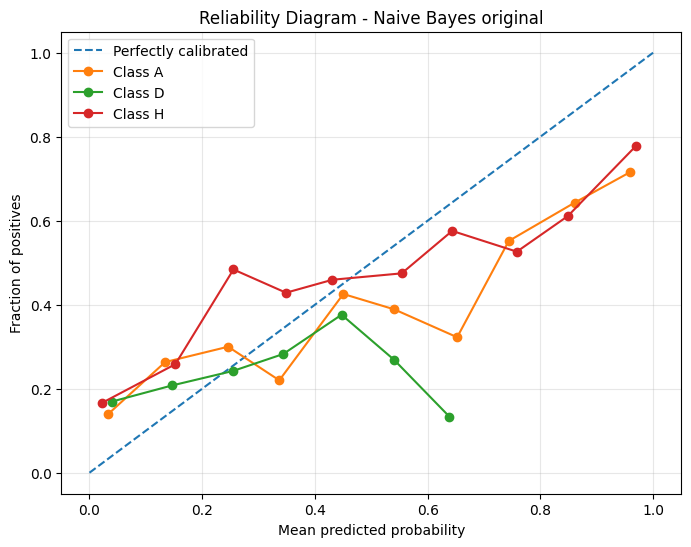

In [208]:
plot_multiclass_reliability(
    y_test,
    y_test_proba_nb,
    nb_model.classes_,
    "Reliability Diagram - Naive Bayes original"
)

We can see that none of the classes is calibrated well enough, and especially class D (tie) isn't even close

**Platt Scaling sobre Naive Bayes**

In [209]:
# Calibramos el modelo ya entrenado usando el conjunto de calibración
# Naive Bayes puede dar probabilidades demasiado extremas por su hipótesis de independencia condicional. Platt Scaling intenta corregir esas probabilidades
nb_platt = CalibratedClassifierCV(          
    nb_model,
    method="sigmoid",
    cv="prefit"         # Indica que el modelo base ya está entrenado. Por eso el calibrador solo debe aprender la transformación de calibración usando X_nb_calib_enc y y_calib
)

nb_platt.fit(X_nb_calib_enc, y_calib)           # Ajusta la calibración usando el conjunto de calibración

y_test_proba_nb_platt = nb_platt.predict_proba(X_nb_test_enc)
y_test_pred_nb_platt = nb_platt.predict(X_nb_test_enc)

print("Naive Bayes calibrated with Platt Scaling.")
print("Classes:", nb_platt.classes_)

Naive Bayes calibrated with Platt Scaling.
Classes: ['A' 'D' 'H']


c:\Users\franf\Desktop\PIA\venv\lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


**Metrics of the calibrated model**

In [210]:
nb_platt_brier = multiclass_brier_score(
    y_test,
    y_test_proba_nb_platt,
    nb_platt.classes_
)

nb_platt_log_loss = log_loss(
    y_test,
    y_test_proba_nb_platt,
    labels=nb_platt.classes_
)

nb_platt_ece = compute_multiclass_ece(
    y_test,
    y_test_proba_nb_platt,
    nb_platt.classes_
)

print("Naive Bayes Platt Scaling calibration metrics")
print("Brier Score:", nb_platt_brier)
print("Log Loss:", nb_platt_log_loss)
print("ECE:", nb_platt_ece)

Naive Bayes Platt Scaling calibration metrics
Brier Score: 0.5643270617235707
Log Loss: 0.9555840298892352
ECE: 0.033966117969734845


**Reliability diagram after Platt scaling**

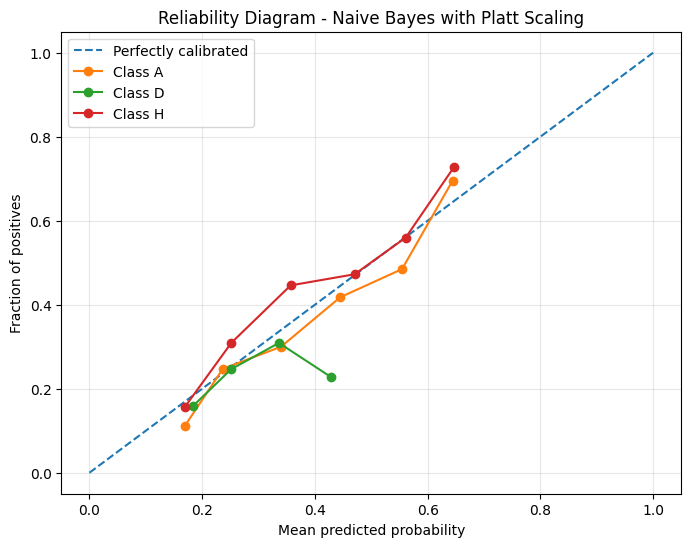

In [211]:
plot_multiclass_reliability(
    y_test,
    y_test_proba_nb_platt,
    nb_platt.classes_,
    "Reliability Diagram - Naive Bayes with Platt Scaling"
)

We can see that classes A and H have now been fairly well calibrated, but D remains a problem, even though it has improved slightly

**Before-and-after comparison**

In [212]:
# Crea una tabla resumen con las métricas del modelo original y calibrado
calibration_comparison_nb = pd.DataFrame([
    {
        "Model": "Naive Bayes original",
        "Brier Score": nb_original_brier,
        "Log Loss": nb_original_log_loss,
        "ECE": nb_original_ece
    },
    {
        "Model": "Naive Bayes Platt Scaling",
        "Brier Score": nb_platt_brier,
        "Log Loss": nb_platt_log_loss,
        "ECE": nb_platt_ece
    }
])

calibration_comparison_nb["Brier improvement"] = (              # Calcula cuánto mejora el Brier Score respecto al original
    nb_original_brier - calibration_comparison_nb["Brier Score"]
)

# Interpretación:
    # Si el valor es positivo, el modelo calibrado mejora
    # Si es negativo, empeora

calibration_comparison_nb["Log Loss improvement"] = (
    nb_original_log_loss - calibration_comparison_nb["Log Loss"]
)

calibration_comparison_nb["ECE improvement"] = (
    nb_original_ece - calibration_comparison_nb["ECE"]
)

print("Calibration comparison:")
display(calibration_comparison_nb)

Calibration comparison:


,Model,Brier Score,Log Loss,ECE,Brier improvement,Log Loss improvement,ECE improvement
0,Naive Bayes original,0.613459,1.145241,0.124088,0.000000,0.000000,0.000000
1,Naive Bayes Platt Scaling,0.564327,0.955584,0.033966,0.049132,0.189657,0.090122


We can clearly see an improvement

**Save calibrated probabilities**

In [213]:
nb_platt_proba_test = pd.DataFrame(
    y_test_proba_nb_platt,
    columns=[f"P_{class_name}_calibrated" for class_name in nb_platt.classes_],
    index=y_test.index
)

nb_calibrated_test_results = nb_test_results.copy()

# Une las probabilidades originales y calibradas en una misma tabla
nb_calibrated_test_results = pd.concat(
    [nb_calibrated_test_results, nb_platt_proba_test],
    axis=1
)

print("First calibrated probabilistic predictions:")
display(nb_calibrated_test_results.head())

First calibrated probabilistic predictions:


,date,ht,at,true_result,predicted_result,P_A,P_D,P_H,P_A_calibrated,P_D_calibrated,P_H_calibrated
4578,2022-10-22,estoril,sp braga,A,A,0.719414,0.213373,0.067214,0.557323,0.246071,0.196606
4579,2022-10-22,sporting,casa pia,H,H,0.005158,0.040704,0.954138,0.161144,0.186227,0.652629
4580,2022-10-23,maritimo,arouca,D,A,0.513750,0.367634,0.118617,0.455628,0.312685,0.231687
4581,2022-10-23,vizela,santa clara,A,D,0.142279,0.452399,0.405322,0.248018,0.352622,0.399360
4582,2022-10-23,chaves,gil vicente,H,D,0.256858,0.526788,0.216354,0.315206,0.390483,0.294311


**10. Select probabilities for later stages**

In [214]:
# Elige automáticamente qué probabilidades usar después
# Para comparación con odds, Reject Option y utilidad necesitamos probabilidades fiables. Usamos Log Loss como criterio porque penaliza especialmente errores confiados
if nb_platt_log_loss < nb_original_log_loss:
    selected_nb_proba_test = y_test_proba_nb_platt
    selected_nb_model_name = "Naive Bayes Platt Scaling"
else:
    selected_nb_proba_test = y_test_proba_nb
    selected_nb_model_name = "Naive Bayes original"

print("Selected probabilities for later stages:", selected_nb_model_name)

Selected probabilities for later stages: Naive Bayes Platt Scaling


### **6.4 Bayesian Optimization over Naive Bayes + Platt Scaling**

**Imports + Prepare data + Base model (unoptimized)**

In [215]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical

from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, balanced_accuracy_score, log_loss

# Convierte las matrices codificadas a tipo entero 
# CategoricalNB espera variables categóricas representadas como enteros. Aunque el OrdinalEncoder devuelve números, suelen venir como float, por ejemplo 1.0, 2.0, etc
X_nb_train_opt = X_nb_train_enc.astype(int)
X_nb_test_opt = X_nb_test_enc.astype(int)

# Modelo base sin optimizar
nb_baseline = CategoricalNB()

nb_baseline.fit(X_nb_train_opt, y_train)

y_pred_baseline = nb_baseline.predict(X_nb_test_opt)
y_proba_baseline = nb_baseline.predict_proba(X_nb_test_opt)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_balanced_accuracy = balanced_accuracy_score(y_test, y_pred_baseline)
baseline_log_loss = log_loss(y_test, y_proba_baseline, labels=nb_baseline.classes_)

print("Baseline Naive Bayes results")
print("Accuracy:", baseline_accuracy)
print("Balanced accuracy:", baseline_balanced_accuracy)
print("Log Loss:", baseline_log_loss)

Baseline Naive Bayes results
Accuracy: 0.5482587064676617
Balanced accuracy: 0.4998014178689641
Log Loss: 1.1452408990766145


**Define search scope**

In [216]:
# Define qué hiperparámetros vamos a optimizar y en qué rangos
search_spaces_nb = {
    "alpha": Real(1e-3, 10.0, prior="log-uniform"),         # alpha controla el suavizado de Naive Bayes. Valores bajos hacen que el modelo se ajuste más a las frecuencias observadas; valores altos suavizan más las probabilidades
    "fit_prior": Categorical([True, False])         # Permite probar si conviene aprender las probabilidades previas de las clases desde los datos (True) o usar una distribución uniforme (False)
}

# prior="log-uniform" --> Hace que la búsqueda explore valores de alpha en escala logarítmica. Esto tiene sentido porque 0.001, 0.01, 0.1, 1 y 10 están en órdenes de magnitud distintos

# 0.001, 0.01, 0.1, 1, 10
# No son valores “separados de forma normal”, sino por órdenes de magnitud.
# Si usamos una búsqueda uniforme normal entre 0.001 y 10, la mayoría de valores probados estarán cerca de números grandes, por ejemplo 6.2, 7.8, 9.1. Apenas probaría valores pequeños como 0.01 o 0.1.
# En cambio, con log-uniform, la búsqueda trata de explorar mejor todas las escalas:
    # entre 0.001 y 0.01
    # entre 0.01 y 0.1
    # entre 0.1 y 1
    # entre 1 y 10

# Con fit_prior=True --> El modelo aprende las proporciones reales del entrenamiento.
# Por ejemplo, si en entrenamiento hay:
# H: 45%
# D: 25%
# A: 30%

# entonces el modelo parte de esa información:
# P(H) = 0.45
# P(D) = 0.25
# P(A) = 0.30
# Esto suele tener sentido en fútbol porque el resultado local no es igual de probable que el empate o la victoria visitante.

# Con fit_prior=False --> El modelo ignora esa distribución y trata todas las clases como igual de probables al inicio:
# P(H) = 0.333
# P(D) = 0.333
# P(A) = 0.333
# Esto puede ser útil si no queremos que el modelo favorezca desde el principio a la clase más frecuente.

**Bayesian Optimization**

In [217]:
bayes_search_nb = BayesSearchCV(
    estimator=CategoricalNB(),
    search_spaces=search_spaces_nb,
    n_iter=30,
    scoring="neg_log_loss",
    cv=3,           # 3-fold: Usa validación cruzada con 3 particiones dentro del entrenamiento
    n_jobs=-1,              # Usa todos los procesadores disponibles
    random_state=RANDOM_STATE,
    optimizer_kwargs={"base_estimator": "GP"},      # Indica que el modelo sustituto de la optimización bayesiana será un Gaussian Process. Este modelo aproxima la relación entre hiperparámetros y rendimiento, y usa incertidumbre para decidir qué probar después
    verbose=1               # Muestra información del progreso de la búsqueda
)

bayes_search_nb.fit(X_nb_train_opt, y_train)

print("Best parameters found by Bayesian Optimization:")
print(bayes_search_nb.best_params_)

print("\nBest CV score:")
print(bayes_search_nb.best_score_)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

**Evaluate the optimized model in a test**

In [218]:
nb_optimized = bayes_search_nb.best_estimator_

y_pred_optimized = nb_optimized.predict(X_nb_test_opt)
y_proba_optimized = nb_optimized.predict_proba(X_nb_test_opt)

optimized_accuracy = accuracy_score(y_test, y_pred_optimized)
optimized_balanced_accuracy = balanced_accuracy_score(y_test, y_pred_optimized)
optimized_log_loss = log_loss(y_test, y_proba_optimized, labels=nb_optimized.classes_)

print("Optimized Naive Bayes results")
print("Accuracy:", optimized_accuracy)
print("Balanced accuracy:", optimized_balanced_accuracy)
print("Log Loss:", optimized_log_loss)

Optimized Naive Bayes results
Accuracy: 0.5502487562189055
Balanced accuracy: 0.49654503957249485
Log Loss: 1.1084946507383597


**Before-and-after comparison**

In [219]:
nb_optimization_comparison = pd.DataFrame([
    {
        "Model": "Naive Bayes baseline",
        "Accuracy": baseline_accuracy,
        "Balanced accuracy": baseline_balanced_accuracy,
        "Log Loss": baseline_log_loss
    },
    {
        "Model": "Naive Bayes optimized",
        "Accuracy": optimized_accuracy,
        "Balanced accuracy": optimized_balanced_accuracy,
        "Log Loss": optimized_log_loss
    }
])

nb_optimization_comparison["Accuracy improvement"] = (
    nb_optimization_comparison["Accuracy"] - baseline_accuracy      # Calcula cuánto cambia la accuracy respecto al baseline
)

nb_optimization_comparison["Balanced accuracy improvement"] = (
    nb_optimization_comparison["Balanced accuracy"] - baseline_balanced_accuracy                
)

nb_optimization_comparison["Log Loss improvement"] = (
    baseline_log_loss - nb_optimization_comparison["Log Loss"]              # Interpretación: Aquí, positivo significa mejora, porque en Log Loss menor es mejor
)

print("Naive Bayes optimization comparison:")
display(nb_optimization_comparison)

Naive Bayes optimization comparison:


,Model,Accuracy,Balanced accuracy,Log Loss,Accuracy improvement,Balanced accuracy improvement,Log Loss improvement
0,Naive Bayes baseline,0.548259,0.499801,1.145241,0.00000,0.000000,0.000000
1,Naive Bayes optimized,0.550249,0.496545,1.108495,0.00199,-0.003256,0.036746


**Search results**

In [220]:
# Convierte todos los resultados de la búsqueda en un DataFrame
nb_bayes_results = pd.DataFrame(bayes_search_nb.cv_results_)

nb_bayes_results_summary = nb_bayes_results[
    ["params", "mean_test_score", "std_test_score", "rank_test_score"]          # Selecciona las columnas más importantes y ordena las configuraciones de mejor a peor.
].sort_values("rank_test_score")

print("Best Bayesian Optimization configurations:")
display(nb_bayes_results_summary.head(10))

Best Bayesian Optimization configurations:


,params,mean_test_score,std_test_score,rank_test_score
10,"{'alpha': 10.0, 'fit_prior': True}",-1.139292,0.027985,1
27,"{'alpha': 9.457755874983231, 'fit_prior': True}",-1.141536,0.028379,2
13,"{'alpha': 9.985085429417243, 'fit_prior': False}",-1.148250,0.025867,3
17,"{'alpha': 7.776381469223014, 'fit_prior': True}",-1.148915,0.029652,4
15,"{'alpha': 6.671051977383557, 'fit_prior': True}",-1.154155,0.030538,5
8,"{'alpha': 6.6360850776123375, 'fit_prior': False}",-1.164949,0.027732,6
26,"{'alpha': 4.199894335996411, 'fit_prior': True}",-1.167263,0.032695,7
16,"{'alpha': 2.473350696218773, 'fit_prior': True}",-1.177918,0.034400,8
3,"{'alpha': 1.7765766649807682, 'fit_prior': True}",-1.182690,0.035157,9
4,"{'alpha': 1.5783879853890563, 'fit_prior': True}",-1.184108,0.035381,10


The metric used is neg_log_loss, which is why the values are negative:

mean_test_score = -1.13929

This is actually equivalent to:

Log Loss ≈ 1.13929

Since BayesSearchCV attempts to maximize the score, the best result is the least negative value, that is:

-1.13929 > -1.14153 > -1.14825

Therefore, the ranking is correct.

**Convergence graph**

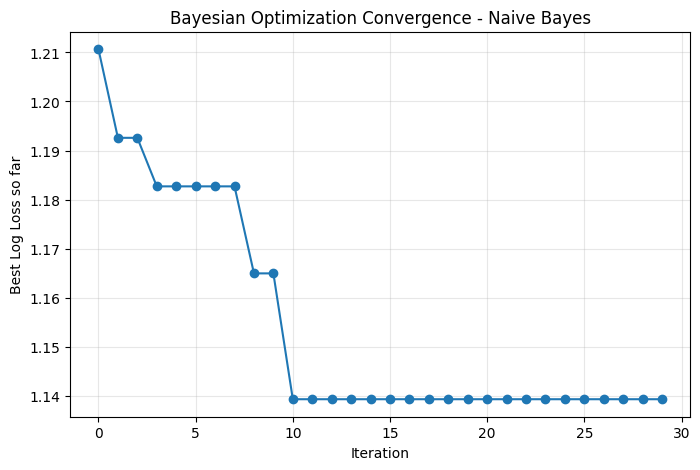

In [221]:
bayes_scores_nb = -np.array(bayes_search_nb.cv_results_["mean_test_score"])     # Convierte neg_log_loss en Log Loss positivo --> La búsqueda maximiza neg_log_loss, pero para interpretarlo queremos ver Log Loss normal, donde menor es mejor
best_log_loss_so_far_nb = np.minimum.accumulate(bayes_scores_nb)        # Calcula el mejor Log Loss encontrado hasta cada iteración, Sirve para ver si la optimización va mejorando a medida que prueba nuevas configuraciones

plt.figure(figsize=(8, 5))
plt.plot(best_log_loss_so_far_nb, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Best Log Loss so far")
plt.title("Bayesian Optimization Convergence - Naive Bayes")
plt.grid(alpha=0.3)
plt.show()

### **7.1. Compare model probabilities with betting odds**

**Prepare a test table with the model's odds and probabilities**

In [222]:
# Crea una tabla solo con los partidos del conjunto de test y conserva la información necesaria: fecha, equipos, resultado real y odds
# La comparación con odds debe hacerse sobre el mismo conjunto donde evaluamos el modelo: el test
utility_results = df_sorted.loc[y_test.index, [
    "date", "ht", "at", "result", "h_odds", "d_odds", "a_odds"
]].copy()

# Así queda claro que esa columna es el resultado real, no una predicción
utility_results = utility_results.rename(columns={
    "result": "true_result"
})

# Convierte las probabilidades del modelo en una tabla con nombres claros
# Necesitamos comparar P_model_A, P_model_D y P_model_H con las probabilidades implícitas del mercado
model_proba_df = pd.DataFrame(
    selected_nb_proba_test,         # Contiene las probabilidades seleccionadas para fases posteriores. En nuestro caso son las calibradas con Platt Scaling
    columns=[f"P_model_{class_name}" for class_name in nb_model.classes_],
    index=y_test.index
)

# Une la información de los partidos con las probabilidades del modelo
utility_results = pd.concat([utility_results, model_proba_df], axis=1)

print("Utility analysis dataset shape:", utility_results.shape)
display(utility_results.head())

Utility analysis dataset shape: (1005, 10)


,date,ht,at,true_result,h_odds,d_odds,a_odds,P_model_A,P_model_D,P_model_H
4578,2022-10-22,estoril,sp braga,A,4.50,3.75,1.66,0.557323,0.246071,0.196606
4579,2022-10-22,sporting,casa pia,H,1.28,5.00,9.00,0.161144,0.186227,0.652629
4580,2022-10-23,maritimo,arouca,D,2.55,3.10,2.70,0.455628,0.312685,0.231687
4581,2022-10-23,vizela,santa clara,A,1.90,3.30,3.80,0.248018,0.352622,0.399360
4582,2022-10-23,chaves,gil vicente,H,2.50,3.40,2.60,0.315206,0.390483,0.294311


**Converting odds to normalized implied probabilities**

In [223]:
# Transforma las odds en probabilidades implícitas sin normalizar
# Una odd baja implica alta probabilidad esperada, y una odd alta implica baja probabilidad esperada
utility_results["raw_market_H"] = 1 / utility_results["h_odds"]
utility_results["raw_market_D"] = 1 / utility_results["d_odds"]
utility_results["raw_market_A"] = 1 / utility_results["a_odds"]

# En apuestas, esta suma suele ser mayor que 1 por el margen de la casa. Esto se llama overround
utility_results["market_overround"] = (
    utility_results["raw_market_H"] +
    utility_results["raw_market_D"] +
    utility_results["raw_market_A"]
)

# Normalizamos para eliminar el margen de la casa de apuestas
utility_results["P_market_H"] = utility_results["raw_market_H"] / utility_results["market_overround"]
utility_results["P_market_D"] = utility_results["raw_market_D"] / utility_results["market_overround"]
utility_results["P_market_A"] = utility_results["raw_market_A"] / utility_results["market_overround"]

print("Market implied probabilities:")
display(utility_results[[
    "h_odds", "d_odds", "a_odds",
    "market_overround",
    "P_market_H", "P_market_D", "P_market_A"
]].head())

Market implied probabilities:


,h_odds,d_odds,a_odds,market_overround,P_market_H,P_market_D,P_market_A
4578,4.50,3.75,1.66,1.091299,0.203631,0.244357,0.552012
4579,1.28,5.00,9.00,1.092361,0.715194,0.183090,0.101716
4580,2.55,3.10,2.70,1.085108,0.361399,0.297280,0.341321
4581,1.90,3.30,3.80,1.092504,0.481752,0.277372,0.240876
4582,2.50,3.40,2.60,1.078733,0.370805,0.272651,0.356544


**Compare the market favorite and the model favorite**

In [224]:
# Guarda en listas las columnas de probabilidades del modelo y del mercado --> Facilita aplicar operaciones sobre las tres clases
model_prob_cols = ["P_model_A", "P_model_D", "P_model_H"]
market_prob_cols = ["P_market_A", "P_market_D", "P_market_H"]

# Identifica qué resultado tiene mayor probabilidad según el modelo
utility_results["model_favorite"] = (
    utility_results[model_prob_cols]
    .idxmax(axis=1)
    .str.replace("P_model_", "")        # P_model_H --> Limpia el texto para dejar solo: H por ejemplo
)

# # Identifica qué resultado tiene mayor probabilidad según el mercado
utility_results["market_favorite"] = (
    utility_results[market_prob_cols]
    .idxmax(axis=1)
    .str.replace("P_market_", "")
)

# Calcula la probabilidad más alta de cada fila
utility_results["model_confidence"] = utility_results[model_prob_cols].max(axis=1)
utility_results["market_confidence"] = utility_results[market_prob_cols].max(axis=1)

# Indica si modelo y mercado coinciden en el resultado favorito
utility_results["favorite_agreement"] = (
    utility_results["model_favorite"] == utility_results["market_favorite"]
)

print("Model vs market favorite:")
display(utility_results[[
    "date", "ht", "at", "true_result",
    "model_favorite", "market_favorite",
    "model_confidence", "market_confidence",
    "favorite_agreement"
]].head())

Model vs market favorite:


,date,ht,at,true_result,model_favorite,market_favorite,model_confidence,market_confidence,favorite_agreement
4578,2022-10-22,estoril,sp braga,A,A,A,0.557323,0.552012,True
4579,2022-10-22,sporting,casa pia,H,H,H,0.652629,0.715194,True
4580,2022-10-23,maritimo,arouca,D,A,H,0.455628,0.361399,False
4581,2022-10-23,vizela,santa clara,A,H,H,0.399360,0.481752,True
4582,2022-10-23,chaves,gil vicente,H,D,H,0.390483,0.370805,False


**Calculate discrepancies between the model and the market**

In [225]:
# Calcula la diferencia entre la probabilidad del modelo y la del mercado para cada resultado
utility_results["diff_A"] = utility_results["P_model_A"] - utility_results["P_market_A"]
utility_results["diff_D"] = utility_results["P_model_D"] - utility_results["P_market_D"]
utility_results["diff_H"] = utility_results["P_model_H"] - utility_results["P_market_H"]

# Interpretación:
    # diff_H > 0 → el modelo da más probabilidad a H que el mercado
    # diff_H < 0 → el modelo da menos probabilidad a H que el mercado

# Calcula la mayor discrepancia absoluta entre modelo y mercado en cada partido
utility_results["max_abs_disagreement"] = utility_results[["diff_A", "diff_D", "diff_H"]].abs().max(axis=1)

print("Largest model-market disagreements:")
display(
    utility_results.sort_values("max_abs_disagreement", ascending=False)[[
        "date", "ht", "at", "true_result",
        "model_favorite", "market_favorite",
        "P_model_A", "P_model_D", "P_model_H",
        "P_market_A", "P_market_D", "P_market_H",
        "diff_A", "diff_D", "diff_H",
        "max_abs_disagreement"
    ]].head(10)
)

Largest model-market disagreements:


,date,ht,at,true_result,model_favorite,market_favorite,P_model_A,P_model_D,P_model_H,P_market_A,P_market_D,P_market_H,diff_A,diff_D,diff_H,max_abs_disagreement
5269,2025-01-25,casa pia,benfica,H,H,A,0.221454,0.234179,0.544367,0.688288,0.199966,0.111746,-0.466834,0.034213,0.432621,0.466834
4909,2023-12-08,benfica,farense,D,H,H,0.359813,0.273817,0.366369,0.072801,0.118301,0.808898,0.287012,0.155516,-0.442528,0.442528
4938,2024-01-06,arouca,benfica,A,H,A,0.231383,0.231233,0.537384,0.638655,0.201681,0.159664,-0.407273,0.029553,0.377720,0.407273
4767,2023-05-06,benfica,sp braga,H,A,H,0.565241,0.227364,0.207395,0.170709,0.223548,0.605743,0.394531,0.003816,-0.398347,0.398347
4892,2023-11-11,guimaraes,porto,A,H,A,0.207804,0.225873,0.566322,0.557621,0.252788,0.189591,-0.349816,-0.026915,0.376731,0.376731
4852,2023-09-24,sp braga,boavista,H,A,H,0.525994,0.211204,0.262803,0.153846,0.230769,0.615385,0.372148,-0.019566,-0.352582,0.372148
5281,2025-02-01,santa clara,casa pia,H,A,H,0.619141,0.209689,0.171170,0.247811,0.303769,0.448420,0.371330,-0.094080,-0.277250,0.371330
5369,2025-04-18,porto,famalicao,H,A,H,0.468308,0.247362,0.284330,0.158298,0.199955,0.641747,0.310010,0.047407,-0.357417,0.357417
4935,2024-01-05,sporting,estoril,H,H,H,0.381585,0.216363,0.402052,0.085375,0.163326,0.751299,0.296210,0.053037,-0.349248,0.349248
5068,2024-04-21,famalicao,portimonense,D,A,H,0.476973,0.278140,0.244888,0.159168,0.251319,0.589513,0.317804,0.026821,-0.344625,0.344625


**Calculate the expected value for each outcome**

In [226]:
# Calcula el valor esperado de apostar a cada resultado según las probabilidades del modelo
utility_results["EV_A"] = utility_results["P_model_A"] * utility_results["a_odds"] - 1          # EV(k) = P_model(k) × odds(k) - 1
utility_results["EV_D"] = utility_results["P_model_D"] * utility_results["d_odds"] - 1
utility_results["EV_H"] = utility_results["P_model_H"] * utility_results["h_odds"] - 1

ev_cols = ["EV_A", "EV_D", "EV_H"]

#  Identifica qué resultado tiene mayor EV en cada partido
utility_results["best_ev_outcome"] = (
    utility_results[ev_cols]
    .idxmax(axis=1)
    .str.replace("EV_", "")
)

# Guarda el mejor EV encontrado entre A, D y H
utility_results["best_ev"] = utility_results[ev_cols].max(axis=1)

print("Expected value examples:")
display(utility_results[[
    "date", "ht", "at", "true_result",
    "EV_A", "EV_D", "EV_H",
    "best_ev_outcome", "best_ev"
]].head())

Expected value examples:


,date,ht,at,true_result,EV_A,EV_D,EV_H,best_ev_outcome,best_ev
4578,2022-10-22,estoril,sp braga,A,-0.074845,-0.077233,-0.115272,A,-0.074845
4579,2022-10-22,sporting,casa pia,H,0.450300,-0.068867,-0.164635,A,0.450300
4580,2022-10-23,maritimo,arouca,D,0.230196,-0.030678,-0.409198,A,0.230196
4581,2022-10-23,vizela,santa clara,A,-0.057532,0.163653,-0.241216,D,0.163653
4582,2022-10-23,chaves,gil vicente,H,-0.180465,0.327643,-0.264223,D,0.327643


**Identify value bets with a minimum threshold**

This means we only place a value bet if the expected return exceeds 5% per unit wagered

In [227]:
value_threshold = 0.05

# Marca si un partido tiene una posible value bet.
utility_results["is_value_bet"] = utility_results["best_ev"] > value_threshold

# Filtra solo los partidos donde hay value bet según nuestro criterio
value_bets = utility_results[utility_results["is_value_bet"]].copy()

print("Value bet threshold:", value_threshold)
print("Number of value bets:", len(value_bets))
print("Percentage of test matches with value bet:", len(value_bets) / len(utility_results))

display(value_bets[[
    "date", "ht", "at", "true_result",
    "model_favorite", "market_favorite",
    "best_ev_outcome", "best_ev",
    "P_model_A", "P_model_D", "P_model_H",
    "P_market_A", "P_market_D", "P_market_H",
    "a_odds", "d_odds", "h_odds"
]].sort_values("best_ev", ascending=False).head(10))

Value bet threshold: 0.05
Number of value bets: 813
Percentage of test matches with value bet: 0.808955223880597


,date,ht,at,true_result,model_favorite,market_favorite,best_ev_outcome,best_ev,P_model_A,P_model_D,P_model_H,P_market_A,P_market_D,P_market_H,a_odds,d_odds,h_odds
4909,2023-12-08,benfica,farense,D,H,H,A,3.677571,0.359813,0.273817,0.366369,0.072801,0.118301,0.808898,13.00,8.00,1.17
5269,2025-01-25,casa pia,benfica,H,H,A,H,3.627119,0.221454,0.234179,0.544367,0.688288,0.199966,0.111746,1.38,4.75,8.50
4797,2023-05-27,benfica,santa clara,H,H,H,A,3.596953,0.158516,0.178490,0.662995,0.031991,0.092775,0.875234,29.00,10.00,1.06
4935,2024-01-05,sporting,estoril,H,H,H,A,3.197439,0.381585,0.216363,0.402052,0.085375,0.163326,0.751299,11.00,5.75,1.25
5224,2024-12-14,sporting,boavista,H,H,H,A,2.672566,0.159677,0.183687,0.656636,0.040657,0.093510,0.865833,23.00,10.00,1.08
5100,2024-05-18,sporting,chaves,H,H,H,A,2.657936,0.159041,0.180986,0.659973,0.040673,0.085044,0.874283,23.00,11.00,1.07
5240,2024-12-23,benfica,estoril,H,H,H,A,2.657936,0.159041,0.180986,0.659973,0.040457,0.097950,0.861593,23.00,9.50,1.08
5158,2024-09-22,sporting,avs,H,H,H,A,2.654719,0.158901,0.181506,0.659593,0.040963,0.078513,0.880523,23.00,12.00,1.07
4613,2022-12-28,porto,arouca,H,H,H,A,2.646711,0.158553,0.178328,0.663119,0.040657,0.116890,0.842452,23.00,8.00,1.11
4812,2023-08-19,benfica,est amadora,H,H,H,A,2.642032,0.158349,0.177871,0.663780,0.040457,0.097950,0.861593,23.00,9.50,1.08


**Cases where the model and the market align**

In [228]:
# Filtra los partidos donde el modelo y el mercado tienen el mismo favorito
agreement_cases = utility_results[utility_results["favorite_agreement"]].copy()

print("Number of agreement cases:", len(agreement_cases))

display(agreement_cases[[
    "date", "ht", "at", "true_result",
    "model_favorite", "market_favorite",
    "model_confidence", "market_confidence",
    "P_model_A", "P_model_D", "P_model_H",
    "P_market_A", "P_market_D", "P_market_H"
]].head(10))

Number of agreement cases: 837


,date,ht,at,true_result,model_favorite,market_favorite,model_confidence,market_confidence,P_model_A,P_model_D,P_model_H,P_market_A,P_market_D,P_market_H
4578,2022-10-22,estoril,sp braga,A,A,A,0.557323,0.552012,0.557323,0.246071,0.196606,0.552012,0.244357,0.203631
4579,2022-10-22,sporting,casa pia,H,H,H,0.652629,0.715194,0.161144,0.186227,0.652629,0.101716,0.183090,0.715194
4581,2022-10-23,vizela,santa clara,A,H,H,0.399360,0.481752,0.248018,0.352622,0.399360,0.240876,0.277372,0.481752
4583,2022-10-23,guimaraes,boavista,H,H,H,0.585378,0.459245,0.190269,0.224353,0.585378,0.262425,0.278330,0.459245
4584,2022-10-24,rio ave,portimonense,H,H,H,0.613003,0.377382,0.176175,0.210821,0.613003,0.342440,0.280178,0.377382
4585,2022-10-28,pacos ferreira,maritimo,A,H,H,0.480301,0.419297,0.227351,0.292348,0.480301,0.285884,0.294818,0.419297
4586,2022-10-29,arouca,sporting,H,A,A,0.658146,0.644172,0.658146,0.180730,0.161123,0.644172,0.222393,0.133436
4587,2022-10-29,benfica,chaves,H,H,H,0.665092,0.794066,0.158027,0.176881,0.665092,0.072077,0.133857,0.794066
4588,2022-10-29,santa clara,porto,D,A,A,0.631607,0.667656,0.631607,0.201884,0.166509,0.667656,0.207715,0.124629
4589,2022-10-30,gil vicente,sp braga,A,A,A,0.627452,0.545003,0.627452,0.204383,0.168165,0.545003,0.246685,0.208312


**Cases where the model and the market differ**

In [229]:
# Filtra los partidos donde modelo y mercado no coinciden
disagreement_cases = utility_results[~utility_results["favorite_agreement"]].copy()

print("Number of disagreement cases:", len(disagreement_cases))

display(disagreement_cases.sort_values("max_abs_disagreement", ascending=False)[[
    "date", "ht", "at", "true_result",
    "model_favorite", "market_favorite",
    "model_confidence", "market_confidence",
    "P_model_A", "P_model_D", "P_model_H",
    "P_market_A", "P_market_D", "P_market_H",
    "max_abs_disagreement"
]].head(10))

Number of disagreement cases: 168


,date,ht,at,true_result,model_favorite,market_favorite,model_confidence,market_confidence,P_model_A,P_model_D,P_model_H,P_market_A,P_market_D,P_market_H,max_abs_disagreement
5269,2025-01-25,casa pia,benfica,H,H,A,0.544367,0.688288,0.221454,0.234179,0.544367,0.688288,0.199966,0.111746,0.466834
4938,2024-01-06,arouca,benfica,A,H,A,0.537384,0.638655,0.231383,0.231233,0.537384,0.638655,0.201681,0.159664,0.407273
4767,2023-05-06,benfica,sp braga,H,A,H,0.565241,0.605743,0.565241,0.227364,0.207395,0.170709,0.223548,0.605743,0.398347
4892,2023-11-11,guimaraes,porto,A,H,A,0.566322,0.557621,0.207804,0.225873,0.566322,0.557621,0.252788,0.189591,0.376731
4852,2023-09-24,sp braga,boavista,H,A,H,0.525994,0.615385,0.525994,0.211204,0.262803,0.153846,0.230769,0.615385,0.372148
5281,2025-02-01,santa clara,casa pia,H,A,H,0.619141,0.448420,0.619141,0.209689,0.171170,0.247811,0.303769,0.448420,0.371330
5369,2025-04-18,porto,famalicao,H,A,H,0.468308,0.641747,0.468308,0.247362,0.284330,0.158298,0.199955,0.641747,0.357417
5068,2024-04-21,famalicao,portimonense,D,A,H,0.476973,0.589513,0.476973,0.278140,0.244888,0.159168,0.251319,0.589513,0.344625
5299,2025-02-15,nacional,estoril,D,A,H,0.615252,0.419297,0.615252,0.200620,0.184128,0.285884,0.294818,0.419297,0.329368
5534,2025-12-14,famalicao,estoril,H,A,H,0.540332,0.527606,0.540332,0.249901,0.209767,0.214454,0.257940,0.527606,0.325878


**Situations where the market sees a clear favorite but the model is uncertain**

In [230]:
# Queremos detectar partidos donde el mercado parece tener una opinión clara, pero el modelo no
market_clear_threshold = 0.55           #  mercado con favorito claro
model_uncertain_threshold = 0.45            #  modelo incierto

market_clear_model_uncertain = utility_results[
    (utility_results["market_confidence"] >= market_clear_threshold) &
    (utility_results["model_confidence"] <= model_uncertain_threshold)
].copy()

print("Market clear favorite but model uncertain:")
print("Number of cases:", len(market_clear_model_uncertain))

display(market_clear_model_uncertain[[
    "date", "ht", "at", "true_result",
    "model_favorite", "market_favorite",
    "model_confidence", "market_confidence",
    "P_model_A", "P_model_D", "P_model_H",
    "P_market_A", "P_market_D", "P_market_H"
]].head(10))

Market clear favorite but model uncertain:
Number of cases: 12


,date,ht,at,true_result,model_favorite,market_favorite,model_confidence,market_confidence,P_model_A,P_model_D,P_model_H,P_market_A,P_market_D,P_market_H
4905,2023-12-03,moreirense,benfica,D,A,A,0.448616,0.625583,0.448616,0.264038,0.287346,0.625583,0.209491,0.164926
4909,2023-12-08,benfica,farense,D,H,H,0.366369,0.808898,0.359813,0.273817,0.366369,0.072801,0.118301,0.808898
4935,2024-01-05,sporting,estoril,H,H,H,0.402052,0.751299,0.381585,0.216363,0.402052,0.085375,0.163326,0.751299
5086,2024-05-05,sp braga,casa pia,H,H,H,0.449319,0.713719,0.285460,0.265222,0.449319,0.105472,0.180809,0.713719
5102,2024-05-18,est amadora,gil vicente,H,H,H,0.364816,0.561866,0.279384,0.355800,0.364816,0.197540,0.240594,0.561866
5212,2024-12-02,guimaraes,gil vicente,H,H,H,0.353319,0.563865,0.337831,0.308851,0.353319,0.188331,0.247804,0.563865
5260,2025-01-18,santa clara,estoril,A,H,H,0.356373,0.552764,0.312027,0.331600,0.356373,0.170854,0.276382,0.552764
5422,2025-08-16,guimaraes,estoril,H,A,H,0.429081,0.551809,0.429081,0.259800,0.311120,0.187615,0.260576,0.551809
5425,2025-08-17,alverca,sp braga,A,A,A,0.406234,0.580061,0.406234,0.326439,0.267327,0.580061,0.240948,0.178990
5460,2025-09-20,santa clara,alverca,H,H,H,0.399360,0.555221,0.248018,0.352622,0.399360,0.147467,0.297312,0.555221


**Overview**

In [231]:
utility_summary = pd.DataFrame({
    "Metric": [
        "Agreement cases",
        "Disagreement cases",
        "Mean model confidence",
        "Mean market confidence",
        "Mean max disagreement",
        "Value bets",
        "Value bet rate"
    ],
    "Value": [
        utility_results["favorite_agreement"].sum(),
        (~utility_results["favorite_agreement"]).sum(),
        utility_results["model_confidence"].mean(),
        utility_results["market_confidence"].mean(),
        utility_results["max_abs_disagreement"].mean(),
        utility_results["is_value_bet"].sum(),
        utility_results["is_value_bet"].mean()
    ]
})

print("Utility analysis summary:")
display(utility_summary)

Utility analysis summary:


,Metric,Value
0,Agreement cases,837.000000
1,Disagreement cases,168.000000
2,Mean model confidence,0.537500
3,Mean market confidence,0.538661
4,Mean max disagreement,0.102091
5,Value bets,813.000000
6,Value bet rate,0.808955


### **Phase 12: Reject Option and Deferral to Odds**

**Final Decision Rule**

We will use this rule:
1. If the model is confident → use the model’s prediction.
2. If the model is not confident and there is a strong value bet, EV > 0.15 → use the value bet.
3. If the model is not confident, there is no strong value bet, but the odds are confident → defer to the odds.
4. If nothing is sufficiently clear → reject / abstain.

**Define thresholds and prepare a decision table**

In [232]:
from sklearn.metrics import accuracy_score

# Define los umbrales de decisión y crea una tabla nueva para aplicar la estrategia final
model_conf_threshold = 0.55         # El modelo solo se considera seguro si su probabilidad máxima es al menos 55%
market_conf_threshold = 0.55        # Las odds solo se consideran claras si la probabilidad implícita máxima del mercado es al menos 55%
value_threshold = 0.15              # Solo aceptamos una value bet si el EV supera el 15%. Es más exigente que el 5%, porque antes vimos que el 5% generaba demasiados casos

# Queremos comparar tres posibles acciones: usar el modelo, deferir a las odds o rechazar. Para eso necesitamos fijar cuándo consideramos que el modelo está seguro, 
# cuándo el mercado está seguro y cuándo una value bet es suficientemente fuerte
decision_results = utility_results.copy()               # Creamos una copia para no modificar la tabla original de utilidad

decision_results["model_prediction"] = decision_results["model_favorite"]
decision_results["market_prediction"] = decision_results["market_favorite"]

# Value bet fuerte: solo si el EV supera el 15%
decision_results["strong_value_bet"] = decision_results["best_ev"] > value_threshold

**Apply the rule to all matches**

In [233]:
# Define la regla de decisión para cada partido
def make_final_decision(row):
    if row["model_confidence"] >= model_conf_threshold:
        return "use_model", row["model_prediction"]
    
    if row["strong_value_bet"]:
        return "value_bet", row["best_ev_outcome"]
    
    if row["market_confidence"] >= market_conf_threshold:
        return "defer_to_odds", row["market_prediction"]
    
    return "reject", "REJECT"

**Final decision-making authority**

In [234]:
# Aplica la función de decisión a todos los partidos del test y guarda el tipo de decisión tomada
# Necesitamos saber, para cada partido, si el sistema usó el modelo, usó una value bet, deferió a odds o rechazó
decisions = decision_results.apply(make_final_decision, axis=1)         # Aplica la función fila por fila. Cada fila representa un partido

decision_results["decision_type"] = [decision[0] for decision in decisions]
decision_results["final_prediction"] = [decision[1] for decision in decisions]

decision_results["accepted"] = decision_results["decision_type"] != "reject"        # Marca si el sistema tomó una decisión o se abstuvo
decision_results["correct_final_prediction"] = (
    decision_results["final_prediction"] == decision_results["true_result"]
)

print("Final decision strategy applied.")
print("Decision types:")
print(decision_results["decision_type"].value_counts())         # Cuenta cuántos partidos caen en cada tipo de decisión

Final decision strategy applied.
Decision types:
decision_type
use_model        507
reject           267
value_bet        228
defer_to_odds      3
Name: count, dtype: int64


**Performance Comparison**

In [235]:
# Comparación de rendimiento

# Estrategia 1: predecir siempre con el modelo --> Calcula la accuracy si siempre usamos el modelo
always_model_accuracy = accuracy_score(
    decision_results["true_result"],
    decision_results["model_prediction"]
)

# Estrategia 2: Reject Option simple usando solo confianza del modelo --> Evalúa una Reject Option simple basada solo en confianza del modelo
model_only_accepted = decision_results["model_confidence"] >= model_conf_threshold      # Acepta solo los partidos donde el modelo está seguro

model_only_coverage = model_only_accepted.mean()
model_only_selective_accuracy = accuracy_score(
    decision_results.loc[model_only_accepted, "true_result"],       # Calcula la cobertura: proporción de partidos donde el modelo decide
    decision_results.loc[model_only_accepted, "model_prediction"]       # ¡OJO! Selective accuray: Calcula la accuracy solo sobre los partidos aceptados
)

# Estrategia 3: regla final con modelo, value bet, odds y rechazo --> Evalúa la estrategia híbrida final: modelo + value bet + odds + rechazo
# Esta es la estrategia completa que queremos defender en el informe
final_accepted = decision_results["accepted"]

final_coverage = final_accepted.mean()
final_selective_accuracy = accuracy_score(
    decision_results.loc[final_accepted, "true_result"],
    decision_results.loc[final_accepted, "final_prediction"]            # Selective accuray también
)

decision_comparison = pd.DataFrame([
    {
        "Strategy": "Always use model",
        "Coverage": 1.0,
        "Accuracy on accepted cases": always_model_accuracy
    },
    {
        "Strategy": "Reject Option - model confidence",
        "Coverage": model_only_coverage,
        "Accuracy on accepted cases": model_only_selective_accuracy
    },
    {
        "Strategy": "Hybrid: model + value bet + odds + reject",
        "Coverage": final_coverage,
        "Accuracy on accepted cases": final_selective_accuracy
    }
])

print("Decision strategy comparison:")
display(decision_comparison)

Decision strategy comparison:


,Strategy,Coverage,Accuracy on accepted cases
0,Always use model,1.000000,0.550249
1,Reject Option - model confidence,0.504478,0.682446
2,Hybrid: model + value bet + odds + reject,0.734328,0.555556


**See examples of each decision**

In [236]:
print("Examples using model:")
display(decision_results[decision_results["decision_type"] == "use_model"][[
    "date", "ht", "at", "true_result",
    "model_prediction", "model_confidence",
    "final_prediction", "decision_type"
]].head())

print("Examples using value bet:")
display(decision_results[decision_results["decision_type"] == "value_bet"][[
    "date", "ht", "at", "true_result",
    "best_ev_outcome", "best_ev",
    "model_confidence",
    "final_prediction", "decision_type"
]].head())

print("Examples deferring to odds:")
display(decision_results[decision_results["decision_type"] == "defer_to_odds"][[
    "date", "ht", "at", "true_result",
    "market_prediction", "market_confidence",
    "model_confidence",
    "final_prediction", "decision_type"
]].head())

print("Examples rejected:")
display(decision_results[decision_results["decision_type"] == "reject"][[
    "date", "ht", "at", "true_result",
    "model_prediction", "model_confidence",
    "market_prediction", "market_confidence",
    "best_ev", "decision_type"
]].head())

Examples using model:


,date,ht,at,true_result,model_prediction,model_confidence,final_prediction,decision_type
4578,2022-10-22,estoril,sp braga,A,A,0.557323,A,use_model
4579,2022-10-22,sporting,casa pia,H,H,0.652629,H,use_model
4583,2022-10-23,guimaraes,boavista,H,H,0.585378,H,use_model
4584,2022-10-24,rio ave,portimonense,H,H,0.613003,H,use_model
4586,2022-10-29,arouca,sporting,H,A,0.658146,A,use_model


Examples using value bet:


,date,ht,at,true_result,best_ev_outcome,best_ev,model_confidence,final_prediction,decision_type
4580,2022-10-23,maritimo,arouca,D,A,0.230196,0.455628,A,value_bet
4581,2022-10-23,vizela,santa clara,A,D,0.163653,0.399360,D,value_bet
4582,2022-10-23,chaves,gil vicente,H,D,0.327643,0.390483,D,value_bet
4590,2022-10-30,casa pia,rio ave,H,A,0.424166,0.374780,A,value_bet
4591,2022-10-30,boavista,vizela,D,D,0.190538,0.375277,D,value_bet


Examples deferring to odds:


,date,ht,at,true_result,market_prediction,market_confidence,model_confidence,final_prediction,decision_type
4607,2022-11-13,portimonense,sp braga,A,A,0.563486,0.534520,A,defer_to_odds
5165,2024-09-29,santa clara,boavista,H,H,0.595964,0.514726,H,defer_to_odds
5468,2025-09-27,santa clara,tondela,A,H,0.558643,0.514726,H,defer_to_odds


Examples rejected:


,date,ht,at,true_result,model_prediction,model_confidence,market_prediction,market_confidence,best_ev,decision_type
4585,2022-10-28,pacos ferreira,maritimo,A,H,0.480301,H,0.419297,0.080677,reject
4594,2022-11-04,gil vicente,portimonense,A,H,0.457067,H,0.422936,0.054071,reject
4600,2022-11-06,maritimo,famalicao,D,A,0.447615,A,0.367087,0.141418,reject
4602,2022-11-07,chaves,santa clara,D,H,0.490302,H,0.408225,0.127694,reject
4605,2022-11-13,casa pia,chaves,A,H,0.473602,H,0.471349,-0.018184,reject


**Final Summary of the Strategy**

In [237]:
decision_summary = pd.DataFrame({
    "Metric": [
        "Model confidence threshold",
        "Market confidence threshold",
        "Value bet threshold",
        "Total matches",
        "Accepted matches",
        "Rejected matches",
        "Final coverage",
        "Final selective accuracy"
    ],
    "Value": [
        model_conf_threshold,
        market_conf_threshold,
        value_threshold,
        len(decision_results),
        final_accepted.sum(),
        (~final_accepted).sum(),
        final_coverage,
        final_selective_accuracy
    ]
})

print("Final strategy summary:")
display(decision_summary)

Final strategy summary:


,Metric,Value
0,Model confidence threshold,0.550000
1,Market confidence threshold,0.550000
2,Value bet threshold,0.150000
3,Total matches,1005.000000
4,Accepted matches,738.000000
5,Rejected matches,267.000000
6,Final coverage,0.734328
7,Final selective accuracy,0.555556
